In [1]:
import sys

sys.path.append("..")

from common.metrics import metrics
from common.preprocessing import preprocessing_cn7
from common.train_test_split import split_data
from common.model_composition import model_composition

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 데이터 불러오기
train_cn7 = pd.read_csv(r"C:\Users\Administrator\Desktop\kamp\1. 사출성형기 AI 데이터셋\1. 사출성형기 AI 데이터셋\moldset_labeled_cn7_되돌림.csv")

In [3]:
X_cn7, y_cn7 = preprocessing_cn7(train_cn7)

print("X shape:", X_cn7.shape)
print("y shape:", y_cn7.shape)

X shape: (1211, 27)
y shape: (1211,)


# 1. 데이터 전처리

### 원본 복사 및 시간형 변환

In [4]:
train_cn7_pre = train_cn7.copy()

train_cn7_pre["TimeStamp"] = pd.to_datetime(
    train_cn7_pre["TimeStamp"],
    errors="coerce"
)

train_cn7_pre = train_cn7_pre.sort_values(
    ["TimeStamp", "RH_LH"]
).reset_index(drop=True)

train_cn7_pre.head()

,original_index,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,...,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4,TimeStamp,PART_NAME,RH_LH
0,0,0,1.679123,1.491397,-0.478017,0.361047,0.97858,-0.711164,1.532018,0.0,...,-0.672350,-1.536620,0.008133,-1.352970,-1.780463,1.023094,1.287574,2020-10-16 04:57:47,CN7 W/S SIDE MLD'G RH,RH
1,2,0,2.080358,1.894372,-0.527100,1.886261,0.97858,-0.711164,1.471608,0.0,...,0.914107,0.504051,-0.915098,-2.263700,-0.874018,1.023094,1.337339,2020-10-16 04:58:48,CN7 W/S SIDE MLD'G LH,LH
2,1,0,2.080358,1.894372,-0.527100,1.886261,0.97858,-0.711164,1.471608,0.0,...,0.914107,0.504051,-0.915098,-2.263700,-0.874018,1.023094,1.337339,2020-10-16 04:58:48,CN7 W/S SIDE MLD'G RH,RH
3,3,0,1.679123,1.894372,-0.527100,1.377857,0.97858,1.202502,1.471608,0.0,...,1.231418,0.886706,-0.299626,0.013158,-1.176164,1.166162,1.337339,2020-10-16 04:59:48,CN7 W/S SIDE MLD'G LH,LH
4,4,0,1.679123,1.894372,-0.527100,1.377857,0.97858,1.202502,1.471608,0.0,...,1.231418,0.886706,-0.299626,0.013158,-1.176164,1.166162,1.337339,2020-10-16 04:59:48,CN7 W/S SIDE MLD'G RH,RH


### 결측치 확인

In [5]:
train_cn7_pre.isnull().sum()

original_index              0
PassOrFail                  0
Injection_Time              0
Filling_Time                0
Plasticizing_Time           0
Cycle_Time                  0
Clamp_Close_Time            0
Cushion_Position            0
Plasticizing_Position       0
Clamp_Open_Position         0
Max_Injection_Speed         0
Max_Screw_RPM               0
Average_Screw_RPM           0
Max_Injection_Pressure      0
Max_Switch_Over_Pressure    0
Max_Back_Pressure           0
Average_Back_Pressure       0
Barrel_Temperature_1        0
Barrel_Temperature_2        0
Barrel_Temperature_3        0
Barrel_Temperature_4        0
Barrel_Temperature_5        0
Barrel_Temperature_6        0
Hopper_Temperature          0
Mold_Temperature_3          0
Mold_Temperature_4          0
TimeStamp                   0
PART_NAME                   0
RH_LH                       0
dtype: int64

### 상수 컬럼 제거

In [6]:
train_cn7_pre = train_cn7_pre.drop(
    columns=["Clamp_Open_Position"]
)

### 원래 행 번호 제거

In [7]:
train_cn7_pre = train_cn7_pre.drop(
    columns=["original_index"]
)

### part name 제거

In [8]:
train_cn7_pre = train_cn7_pre.drop(
    columns=["PART_NAME"]
)

### RH LH 숫자로 변환

In [9]:
train_cn7_pre["Side_RH"] = (
    train_cn7_pre["RH_LH"] == "RH"
).astype(int)

In [10]:
train_cn7_pre[
    ["RH_LH", "Side_RH"]
].value_counts()

RH_LH  Side_RH
RH     1          606
LH     0          605
Name: count, dtype: int64

In [11]:
train_cn7_pre = train_cn7_pre.drop(
    columns=["RH_LH"]
)

### timestamp는 모델 입력 변수와 그룹 변수로 분리

In [12]:
groups_cn7 = train_cn7_pre["TimeStamp"].copy()

In [13]:
train_cn7_pre = train_cn7_pre.drop(
    columns=["TimeStamp"]
)

In [14]:
cn7_work = train_cn7_pre.copy()

cn7_work["TimeStamp"] = groups_cn7.values

cn7_work.head()

,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Max_Injection_Speed,Max_Screw_RPM,...,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4,Side_RH,TimeStamp
0,0,1.679123,1.491397,-0.478017,0.361047,0.97858,-0.711164,1.532018,-1.152398,-0.795730,...,-1.598068,-0.672350,-1.536620,0.008133,-1.352970,-1.780463,1.023094,1.287574,1,2020-10-16 04:57:47
1,0,2.080358,1.894372,-0.527100,1.886261,0.97858,-0.711164,1.471608,-1.347095,0.049553,...,0.622557,0.914107,0.504051,-0.915098,-2.263700,-0.874018,1.023094,1.337339,0,2020-10-16 04:58:48
2,0,2.080358,1.894372,-0.527100,1.886261,0.97858,-0.711164,1.471608,-1.347095,0.049553,...,0.622557,0.914107,0.504051,-0.915098,-2.263700,-0.874018,1.023094,1.337339,1,2020-10-16 04:58:48
3,0,1.679123,1.894372,-0.527100,1.377857,0.97858,1.202502,1.471608,-1.347095,1.740153,...,-0.765355,1.231418,0.886706,-0.299626,0.013158,-1.176164,1.166162,1.337339,0,2020-10-16 04:59:48
4,0,1.679123,1.894372,-0.527100,1.377857,0.97858,1.202502,1.471608,-1.347095,1.740153,...,-0.765355,1.231418,0.886706,-0.299626,0.013158,-1.176164,1.166162,1.337339,1,2020-10-16 04:59:48


In [15]:
cn7_work.columns.tolist()

['PassOrFail',
 'Injection_Time',
 'Filling_Time',
 'Plasticizing_Time',
 'Cycle_Time',
 'Clamp_Close_Time',
 'Cushion_Position',
 'Plasticizing_Position',
 'Max_Injection_Speed',
 'Max_Screw_RPM',
 'Average_Screw_RPM',
 'Max_Injection_Pressure',
 'Max_Switch_Over_Pressure',
 'Max_Back_Pressure',
 'Average_Back_Pressure',
 'Barrel_Temperature_1',
 'Barrel_Temperature_2',
 'Barrel_Temperature_3',
 'Barrel_Temperature_4',
 'Barrel_Temperature_5',
 'Barrel_Temperature_6',
 'Hopper_Temperature',
 'Mold_Temperature_3',
 'Mold_Temperature_4',
 'Side_RH',
 'TimeStamp']

### 센서컬럼 자동 지정

In [16]:
SENSOR_COLS = [
    col for col in cn7_work.columns
    if col not in ["PassOrFail", "Side_RH", "TimeStamp"]
]

print("센서 변수 개수:", len(SENSOR_COLS))
print(SENSOR_COLS)

센서 변수 개수: 23
['Injection_Time', 'Filling_Time', 'Plasticizing_Time', 'Cycle_Time', 'Clamp_Close_Time', 'Cushion_Position', 'Plasticizing_Position', 'Max_Injection_Speed', 'Max_Screw_RPM', 'Average_Screw_RPM', 'Max_Injection_Pressure', 'Max_Switch_Over_Pressure', 'Max_Back_Pressure', 'Average_Back_Pressure', 'Barrel_Temperature_1', 'Barrel_Temperature_2', 'Barrel_Temperature_3', 'Barrel_Temperature_4', 'Barrel_Temperature_5', 'Barrel_Temperature_6', 'Hopper_Temperature', 'Mold_Temperature_3', 'Mold_Temperature_4']


### cycle 단위 데이터 생성

In [17]:
cn7_cycle = (
    cn7_work
    .sort_values("TimeStamp")
    .drop_duplicates(
        subset=["TimeStamp"],
        keep="first"
    )
    [["TimeStamp"] + SENSOR_COLS]
    .reset_index(drop=True)
)

print("전체 행 수:", len(cn7_work))
print("고유 Cycle 수:", len(cn7_cycle))

cn7_cycle.head()

전체 행 수: 1211
고유 Cycle 수: 606


,TimeStamp,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Max_Injection_Speed,Max_Screw_RPM,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
0,2020-10-16 04:57:47,1.679123,1.491397,-0.478017,0.361047,0.97858,-0.711164,1.532018,-1.152398,-0.795730,...,-0.533773,0.729073,-1.598068,-0.672350,-1.536620,0.008133,-1.352970,-1.780463,1.023094,1.287574
1,2020-10-16 04:58:48,2.080358,1.894372,-0.527100,1.886261,0.97858,-0.711164,1.471608,-1.347095,0.049553,...,-0.533773,0.056153,0.622557,0.914107,0.504051,-0.915098,-2.263700,-0.874018,1.023094,1.337339
2,2020-10-16 04:59:48,1.679123,1.894372,-0.527100,1.377857,0.97858,1.202502,1.471608,-1.347095,1.740153,...,-0.533773,0.729073,-0.765355,1.231418,0.886706,-0.299626,0.013158,-1.176164,1.166162,1.337339
3,2020-10-16 05:00:46,1.277888,1.088442,-0.576184,1.886261,0.97858,-0.711164,1.471608,-0.763018,0.894853,...,-0.152634,0.280414,0.067358,0.596893,1.269321,0.008133,0.013158,-0.571865,1.166162,1.337339
4,2020-10-16 05:01:46,1.277888,1.088442,-0.478017,1.377857,0.97858,-0.711164,1.532018,-0.957708,-1.641030,...,-0.533773,-0.841164,0.344957,-0.037728,1.141770,0.008133,0.013158,-1.075448,1.166162,1.337339


### diff 파생번수 생성(생산중단 구간 부분)

In [18]:
cn7_cycle["time_gap_sec"] = (
    cn7_cycle["TimeStamp"]
    .diff()
    .dt.total_seconds()
)

cn7_cycle["session_id"] = (
    cn7_cycle["time_gap_sec"]
    .gt(300)
    .cumsum()
)

cn7_cycle[
    ["TimeStamp", "time_gap_sec", "session_id"]
].head(10)

,TimeStamp,time_gap_sec,session_id
0,2020-10-16 04:57:47,NaN,0
1,2020-10-16 04:58:48,61.0,0
2,2020-10-16 04:59:48,60.0,0
3,2020-10-16 05:00:46,58.0,0
4,2020-10-16 05:01:46,60.0,0
5,2020-10-16 05:02:46,60.0,0
6,2020-10-16 05:03:44,58.0,0
7,2020-10-16 05:04:44,60.0,0
8,2020-10-16 05:05:45,61.0,0
9,2020-10-16 05:06:43,58.0,0


In [19]:
for col in SENSOR_COLS:
    cn7_cycle[f"{col}_diff1"] = (
        cn7_cycle
        .groupby("session_id")[col]
        .diff()
    )

In [20]:
diff_cols = [
    col for col in cn7_cycle.columns
    if col.endswith("_diff1")
]

print("diff 변수 개수:", len(diff_cols))

cn7_cycle[
    ["TimeStamp"] + diff_cols[:5]
].head()

diff 변수 개수: 23


,TimeStamp,Injection_Time_diff1,Filling_Time_diff1,Plasticizing_Time_diff1,Cycle_Time_diff1,Clamp_Close_Time_diff1
0,2020-10-16 04:57:47,NaN,NaN,NaN,NaN,NaN
1,2020-10-16 04:58:48,0.401235,0.402974,-0.049084,1.525214,0.0
2,2020-10-16 04:59:48,-0.401235,0.000000,0.000000,-0.508405,0.0
3,2020-10-16 05:00:46,-0.401235,-0.805929,-0.049084,0.508405,0.0
4,2020-10-16 05:01:46,0.000000,0.000000,0.098167,-0.508405,0.0


#### 첫 cycle의 nan 처리

In [21]:
cn7_cycle[diff_cols] = (
    cn7_cycle[diff_cols]
    .fillna(0)
)

In [22]:
cn7_cycle[diff_cols].isnull().sum().sum()

np.int64(0)

### diff 1 병합

In [23]:
cn7_work = cn7_work.merge(
    cn7_cycle[
        ["TimeStamp"] + diff_cols
    ],
    on="TimeStamp",
    how="left"
)

In [24]:
print("cn7_work shape:", cn7_work.shape)

cn7_work[
    [
        "TimeStamp",
        "Side_RH",
        SENSOR_COLS[0],
        f"{SENSOR_COLS[0]}_diff1"
    ]
].head(10)

cn7_work shape: (1211, 49)


,TimeStamp,Side_RH,Injection_Time,Injection_Time_diff1
0,2020-10-16 04:57:47,1,1.679123,0.000000
1,2020-10-16 04:58:48,0,2.080358,0.401235
2,2020-10-16 04:58:48,1,2.080358,0.401235
3,2020-10-16 04:59:48,0,1.679123,-0.401235
4,2020-10-16 04:59:48,1,1.679123,-0.401235
5,2020-10-16 05:00:46,0,1.277888,-0.401235
6,2020-10-16 05:00:46,1,1.277888,-0.401235
7,2020-10-16 05:01:46,0,1.277888,0.000000
8,2020-10-16 05:01:46,1,1.277888,0.000000
9,2020-10-16 05:02:46,0,0.876653,-0.401235


In [25]:
print("전체 행 수:", len(cn7_work))

전체 행 수: 1211


In [26]:
cn7_work[diff_cols].isnull().sum().sum()

np.int64(0)

### rolling 생성

> 이동구간 통계

shift(1) -> 현재 제외, 직전 5개만 사용

In [27]:
ROLL_WINDOW = 5

for col in SENSOR_COLS:
    # 직전 5개 Cycle 평균
    cn7_cycle[f"{col}_roll5_mean"] = (
        cn7_cycle
        .groupby("session_id")[col]
        .transform(
            lambda x: x.shift(1).rolling(
                window=ROLL_WINDOW,
                min_periods=1
            ).mean()
        )
    )

    # 직전 5개 Cycle 표준편차
    cn7_cycle[f"{col}_roll5_std"] = (
        cn7_cycle
        .groupby("session_id")[col]
        .transform(
            lambda x: x.shift(1).rolling(
                window=ROLL_WINDOW,
                min_periods=2
            ).std()
        )
    )

In [28]:
roll_mean_cols = [
    col for col in cn7_cycle.columns
    if col.endswith("_roll5_mean")
]

roll_std_cols = [
    col for col in cn7_cycle.columns
    if col.endswith("_roll5_std")
]

print("Rolling Mean:", len(roll_mean_cols))
print("Rolling Std :", len(roll_std_cols))

Rolling Mean: 23
Rolling Std : 23


In [29]:
cn7_cycle[
    [
        "TimeStamp",
        "Injection_Time",
        "Injection_Time_diff1",
        "Injection_Time_roll5_mean",
        "Injection_Time_roll5_std"
    ]
].head(10)

,TimeStamp,Injection_Time,Injection_Time_diff1,Injection_Time_roll5_mean,Injection_Time_roll5_std
0,2020-10-16 04:57:47,1.679123,0.000000,NaN,NaN
1,2020-10-16 04:58:48,2.080358,0.401235,1.679123,NaN
2,2020-10-16 04:59:48,1.679123,-0.401235,1.879741,0.283716
3,2020-10-16 05:00:46,1.277888,-0.401235,1.812868,0.231653
4,2020-10-16 05:01:46,1.277888,0.000000,1.679123,0.327607
5,2020-10-16 05:02:46,0.876653,-0.401235,1.598876,0.335697
6,2020-10-16 05:03:44,0.475456,-0.401197,1.438382,0.457478
7,2020-10-16 05:04:44,0.876653,0.401197,1.117402,0.457465
8,2020-10-16 05:05:45,1.277888,0.401235,0.956908,0.335684
9,2020-10-16 05:06:43,1.277888,0.000000,0.956908,0.335684


In [30]:
rolling_cols = roll_mean_cols + roll_std_cols

cn7_cycle[rolling_cols] = (
    cn7_cycle[rolling_cols]
    .fillna(0)
)

In [31]:
cn7_cycle[rolling_cols].isnull().sum().sum()

np.int64(0)

In [32]:
cn7_work = cn7_work.merge(
    cn7_cycle[
        ["TimeStamp"] + rolling_cols
    ],
    on="TimeStamp",
    how="left"
)

In [33]:
print(cn7_work.shape)
print("행 수:", len(cn7_work))

(1211, 95)
행 수: 1211


In [34]:
cn7_work[rolling_cols].isnull().sum().sum()

np.int64(0)

### deviation 생성

> 현재값 - 직전 5개 평균

현재 값이 최근 5개 평균에서 얼마나 벗어났는가

In [35]:
for col in SENSOR_COLS:
    cn7_cycle[f"{col}_roll5_dev"] = (
        cn7_cycle[col]
        - cn7_cycle[f"{col}_roll5_mean"]
    )

In [36]:
dev_cols = [
    col for col in cn7_cycle.columns
    if col.endswith("_roll5_dev")
]

print("Deviation 변수 개수:", len(dev_cols))
print(dev_cols[:5])

Deviation 변수 개수: 23
['Injection_Time_roll5_dev', 'Filling_Time_roll5_dev', 'Plasticizing_Time_roll5_dev', 'Cycle_Time_roll5_dev', 'Clamp_Close_Time_roll5_dev']


In [37]:
cn7_cycle[
    [
        "TimeStamp",
        "Injection_Time",
        "Injection_Time_roll5_mean",
        "Injection_Time_roll5_dev"
    ]
].head(10)

,TimeStamp,Injection_Time,Injection_Time_roll5_mean,Injection_Time_roll5_dev
0,2020-10-16 04:57:47,1.679123,0.000000,1.679123
1,2020-10-16 04:58:48,2.080358,1.679123,0.401235
2,2020-10-16 04:59:48,1.679123,1.879741,-0.200618
3,2020-10-16 05:00:46,1.277888,1.812868,-0.534980
4,2020-10-16 05:01:46,1.277888,1.679123,-0.401235
5,2020-10-16 05:02:46,0.876653,1.598876,-0.722223
6,2020-10-16 05:03:44,0.475456,1.438382,-0.962926
7,2020-10-16 05:04:44,0.876653,1.117402,-0.240749
8,2020-10-16 05:05:45,1.277888,0.956908,0.320980
9,2020-10-16 05:06:43,1.277888,0.956908,0.320980


In [38]:
cn7_cycle[dev_cols].isnull().sum().sum()

np.int64(0)

In [39]:
cn7_work = cn7_work.merge(
    cn7_cycle[
        ["TimeStamp"] + dev_cols
    ],
    on="TimeStamp",
    how="left"
)

In [40]:
print("행 수:", len(cn7_work))
print("전체 컬럼 수:", cn7_work.shape[1])

print(
    "Deviation 결측:",
    cn7_work[dev_cols].isnull().sum().sum()
)

행 수: 1211
전체 컬럼 수: 118
Deviation 결측: 0


### 지금까지의 파생변수 의미

Injection_Time
→ 현재 공정값

Injection_Time_diff1
→ 바로 직전 Cycle보다 얼마나 변했나

Injection_Time_roll5_mean
→ 최근 5 Cycle의 평소 수준은 어땠나

Injection_Time_roll5_std
→ 최근 5 Cycle이 얼마나 불안정했나

Injection_Time_roll5_dev
→ 현재값이 최근 수준에서 얼마나 벗어났나

# 2. 최종 데이터 점검

### 최종 컬럼 및 로우 수 확인

In [41]:
print("CN7 shape:", cn7_work.shape)
print("행 수:", len(cn7_work))
print("컬럼 수:", cn7_work.shape[1])

print("\n전체 결측치:")
print(cn7_work.isnull().sum().sum())

CN7 shape: (1211, 118)
행 수: 1211
컬럼 수: 118

전체 결측치:
0


### 무한대 값 확인

In [42]:
import numpy as np

num_cols = cn7_work.select_dtypes(include=np.number).columns

print(
    "inf 개수:",
    np.isinf(cn7_work[num_cols]).sum().sum()
)

inf 개수: 0


### 모델에 넣지 않을 컬럼 제거

original_index   
Part_Name   
RH_LH   
Clamp_Open_Position

In [43]:
cn7_work.columns.tolist()

['PassOrFail',
 'Injection_Time',
 'Filling_Time',
 'Plasticizing_Time',
 'Cycle_Time',
 'Clamp_Close_Time',
 'Cushion_Position',
 'Plasticizing_Position',
 'Max_Injection_Speed',
 'Max_Screw_RPM',
 'Average_Screw_RPM',
 'Max_Injection_Pressure',
 'Max_Switch_Over_Pressure',
 'Max_Back_Pressure',
 'Average_Back_Pressure',
 'Barrel_Temperature_1',
 'Barrel_Temperature_2',
 'Barrel_Temperature_3',
 'Barrel_Temperature_4',
 'Barrel_Temperature_5',
 'Barrel_Temperature_6',
 'Hopper_Temperature',
 'Mold_Temperature_3',
 'Mold_Temperature_4',
 'Side_RH',
 'TimeStamp',
 'Injection_Time_diff1',
 'Filling_Time_diff1',
 'Plasticizing_Time_diff1',
 'Cycle_Time_diff1',
 'Clamp_Close_Time_diff1',
 'Cushion_Position_diff1',
 'Plasticizing_Position_diff1',
 'Max_Injection_Speed_diff1',
 'Max_Screw_RPM_diff1',
 'Average_Screw_RPM_diff1',
 'Max_Injection_Pressure_diff1',
 'Max_Switch_Over_Pressure_diff1',
 'Max_Back_Pressure_diff1',
 'Average_Back_Pressure_diff1',
 'Barrel_Temperature_1_diff1',
 'Barre

# 3. x y group 분리

In [44]:
TARGET = "PassOrFail"

groups_cn7 = cn7_work["TimeStamp"].copy()

X_cn7 = cn7_work.drop(
    columns=[TARGET, "TimeStamp"]
).copy()

y_cn7 = cn7_work[TARGET].copy()

In [45]:
print("X shape      :", X_cn7.shape)
print("y shape      :", y_cn7.shape)
print("Group 개수   :", groups_cn7.nunique())

print("\nTarget 분포")
print(y_cn7.value_counts())

print("\nTarget 비율")
print(y_cn7.value_counts(normalize=True))

X shape      : (1211, 116)
y shape      : (1211,)
Group 개수   : 606

Target 분포
PassOrFail
0    1194
1      17
Name: count, dtype: int64

Target 비율
PassOrFail
0    0.985962
1    0.014038
Name: proportion, dtype: float64


### 컬럼 타입 확인

In [46]:
X_cn7.dtypes.value_counts()

float64    115
int64        1
Name: count, dtype: int64

In [47]:
X_cn7.select_dtypes(
    exclude=np.number
).columns.tolist()

[]

### 혹시 모르니까 데이터 저장

In [48]:
cn7_work.to_csv(
    "train_cn7_preprocessed.csv",
    index=False,
    encoding="utf-8-sig"
)

### 4. train test 분리

StratifiedGroupKFold 

동일 TimeStamp의 LH/RH가 동일 생산 Cycle의 센서값을 공유하므로, 같은 Cycle이 학습셋과 검증셋에 동시에 포함되는 데이터 누수를 방지하기 위해 TimeStamp를 Group으로 설정하였다. 또한 정상 1,194건 대비 불량 17건으로 클래스 불균형이 매우 심하므로, Fold별 정상/불량 비율을 최대한 유지하기 위해 StratifiedGroupKFold를 사용하였다.

In [49]:
from sklearn.model_selection import StratifiedGroupKFold


sgkf = StratifiedGroupKFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

for fold, (train_idx, test_idx) in enumerate(
    sgkf.split(X_cn7, y_cn7, groups=groups_cn7),
    start=1
):
    print(f"\n{'='*60}")
    print(f"Fold {fold}")
    print(f"{'='*60}")

    X_train_cn7 = X_cn7.iloc[train_idx]
    X_test_cn7  = X_cn7.iloc[test_idx]

    y_train_cn7 = y_cn7.iloc[train_idx]
    y_test_cn7  = y_cn7.iloc[test_idx]

    print("Train shape:", X_train_cn7.shape)
    print("Test shape :", X_test_cn7.shape)

    print(
        "Train target:",
        y_train_cn7.value_counts().to_dict()
    )

    print(
        "Test target:",
        y_test_cn7.value_counts().to_dict()
    )

    model_composition(
        X_train_cn7,
        X_test_cn7,
        y_train_cn7,
        y_test_cn7
    )


Fold 1
Train shape: (909, 116)
Test shape : (302, 116)
Train target: {0: 896, 1: 13}
Test target: {0: 298, 1: 4}

[Logistic Regression]
Accuracy : 0.9867549668874173
Precision: 0.5
Recall   : 0.5
F1       : 0.5
PR-AUC   : 0.775

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,296,2
Actual Defect,2,2



[Random Forest]
Accuracy : 0.9933774834437086
Precision: 1.0
Recall   : 0.5
F1       : 0.6666666666666666
PR-AUC   : 0.7916666666666666

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,2,2



[LightGBM]
Accuracy : 0.9900662251655629
Precision: 1.0
Recall   : 0.25
F1       : 0.4
PR-AUC   : 0.9166666666666666

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,3,1



[XGBoost]
Accuracy : 0.9900662251655629
Precision: 0.6666666666666666
Recall   : 0.5
F1       : 0.5714285714285714
PR-AUC   : 0.75

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,297,1
Actual Defect,2,2



[CatBoost]
Accuracy : 0.9966887417218543
Precision: 1.0
Recall   : 0.75
F1       : 0.8571428571428571
PR-AUC   : 0.8409090909090909

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,1,3



Fold 2
Train shape: (907, 116)
Test shape : (304, 116)
Train target: {0: 894, 1: 13}
Test target: {0: 300, 1: 4}

[Logistic Regression]
Accuracy : 0.9868421052631579
Precision: 0.0
Recall   : 0.0
F1       : 0.0
PR-AUC   : 0.10684329710144928

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,300,0
Actual Defect,4,0



[Random Forest]
Accuracy : 0.9868421052631579
Precision: 0.0
Recall   : 0.0
F1       : 0.0
PR-AUC   : 0.10813492063492063

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,300,0
Actual Defect,4,0



[LightGBM]
Accuracy : 0.9901315789473685
Precision: 1.0
Recall   : 0.25
F1       : 0.4
PR-AUC   : 0.3732638888888889

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,300,0
Actual Defect,3,1



[XGBoost]
Accuracy : 0.9868421052631579
Precision: 0.0
Recall   : 0.0
F1       : 0.0
PR-AUC   : 0.25476190476190474

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,300,0
Actual Defect,4,0



[CatBoost]
Accuracy : 0.9868421052631579
Precision: 0.0
Recall   : 0.0
F1       : 0.0
PR-AUC   : 0.21651785714285715

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,300,0
Actual Defect,4,0



Fold 3
Train shape: (909, 116)
Test shape : (302, 116)
Train target: {0: 896, 1: 13}
Test target: {0: 298, 1: 4}

[Logistic Regression]
Accuracy : 0.9933774834437086
Precision: 1.0
Recall   : 0.5
F1       : 0.6666666666666666
PR-AUC   : 0.7219827586206897

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,2,2



[Random Forest]
Accuracy : 0.9933774834437086
Precision: 1.0
Recall   : 0.5
F1       : 0.6666666666666666
PR-AUC   : 0.7125

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,2,2



[LightGBM]
Accuracy : 0.9933774834437086
Precision: 1.0
Recall   : 0.5
F1       : 0.6666666666666666
PR-AUC   : 1.0

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,2,2



[XGBoost]
Accuracy : 0.9900662251655629
Precision: 1.0
Recall   : 0.25
F1       : 0.4
PR-AUC   : 0.7784090909090909

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,3,1



[CatBoost]
Accuracy : 0.9933774834437086
Precision: 1.0
Recall   : 0.5
F1       : 0.6666666666666666
PR-AUC   : 0.85

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,2,2



Fold 4
Train shape: (908, 116)
Test shape : (303, 116)
Train target: {0: 896, 1: 12}
Test target: {0: 298, 1: 5}

[Logistic Regression]
Accuracy : 0.9900990099009901
Precision: 1.0
Recall   : 0.4
F1       : 0.5714285714285714
PR-AUC   : 0.6570707070707071

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,3,2



[Random Forest]
Accuracy : 0.9834983498349835
Precision: 0.0
Recall   : 0.0
F1       : 0.0
PR-AUC   : 0.7961904761904761

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,5,0



[LightGBM]
Accuracy : 0.9867986798679867
Precision: 1.0
Recall   : 0.2
F1       : 0.3333333333333333
PR-AUC   : 1.0

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,4,1



[XGBoost]
Accuracy : 0.9900990099009901
Precision: 1.0
Recall   : 0.4
F1       : 0.5714285714285714
PR-AUC   : 0.8766666666666667

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,3,2



[CatBoost]
Accuracy : 0.9867986798679867
Precision: 1.0
Recall   : 0.2
F1       : 0.3333333333333333
PR-AUC   : 0.7282828282828282

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,4,1


| 모델 | 4-Fold 평균 PR-AUC | 평균 Recall | 해석 |
|---|---:|---:|---|
| Logistic | 0.565 | 0.350 | baseline으로 괜찮음 |
| Random Forest | 0.602 | 0.250 | threshold에서 불량을 많이 놓침 |
| **LightGBM** | **0.822** | 0.300 | **현재 ranking 성능 가장 좋음** |
| XGBoost | 0.665 | 0.288 | 준수 |
| CatBoost | 0.659 | **0.363** | Recall은 상대적으로 좋음 |

PR-AUC : 실제 불량에게 정상보다 높은 확률을 잘 부여했는가  
recall : 확률 ranking은 상당히 괜찮은데, 0.5 threshold가 이 데이터에 맞지 않는다

CN7의 공정 변수에서 불량을 구분할 수 있는 신호가 확인되었고, 특히 LightGBM에서 높은 PR-AUC를 보였으나, 소수 불량 표본으로 Fold 간 변동성이 높아 추가 검증이 필요하다.

# 새로운 방식

### 새로운 featuer 세트 생성

In [50]:
feature_sets_cn7 = {
    "V0_original": (
        SENSOR_COLS
        + ["Side_RH"]
    ),

    "V1_diff": (
        SENSOR_COLS
        + ["Side_RH"]
        + diff_cols
    ),

    "V2_roll_mean": (
        SENSOR_COLS
        + ["Side_RH"]
        + diff_cols
        + roll_mean_cols
    ),

    "V3_roll_std": (
        SENSOR_COLS
        + ["Side_RH"]
        + diff_cols
        + roll_mean_cols
        + roll_std_cols
    ),

    "V4_deviation": (
        SENSOR_COLS
        + ["Side_RH"]
        + diff_cols
        + roll_mean_cols
        + roll_std_cols
        + dev_cols
    )
}

In [51]:
for name, cols in feature_sets_cn7.items():
    print(name, ":", len(cols))

V0_original : 24
V1_diff : 47
V2_roll_mean : 70
V3_roll_std : 93
V4_deviation : 116


### 같은 fold 고정

In [52]:
from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

cn7_splits = list(
    sgkf.split(
        X_cn7,
        y_cn7,
        groups=groups_cn7
    )
)

### v0 ~ v4 전체 비교

In [53]:
%%capture cn7_result

for version, feature_cols in feature_sets_cn7.items():

    print("\n")
    print("#" * 80)
    print(f"CN7 FEATURE SET : {version}")
    print(f"Feature Count   : {len(feature_cols)}")
    print("#" * 80)

    X_version = X_cn7[feature_cols]

    for fold, (train_idx, test_idx) in enumerate(
        cn7_splits,
        start=1
    ):
        print("\n")
        print("=" * 70)
        print(f"{version} | Fold {fold}")
        print("=" * 70)

        X_train_cn7 = X_version.iloc[train_idx]
        X_test_cn7  = X_version.iloc[test_idx]

        y_train_cn7 = y_cn7.iloc[train_idx]
        y_test_cn7  = y_cn7.iloc[test_idx]

        print(
            "Train:",
            X_train_cn7.shape,
            "| Target:",
            y_train_cn7.value_counts().to_dict()
        )

        print(
            "Test :",
            X_test_cn7.shape,
            "| Target:",
            y_test_cn7.value_counts().to_dict()
        )

        model_composition(
            X_train_cn7,
            X_test_cn7,
            y_train_cn7,
            y_test_cn7
        )

| Feature Set | 모델 | 평균 PR-AUC | 평균 Recall | 평균 F1 |
|---|---|---:|---:|---:|
| V0 Original 24개 | LightGBM | 0.535 | 0.288 | 0.392 |
| V1 + Diff 47개 | CatBoost | 0.477 | 0.225 | 0.310 |
| **V2 + Rolling Mean 70개** | **LightGBM** | **0.799** | **0.400** | **0.502** |
| V3 + Rolling Std 93개 | LightGBM | 0.803 | 0.363 | 0.481 |
| **V4 + Deviation 116개** | **LightGBM** | **0.823** | 0.300 | 0.450 |

V0 Original
PR-AUC 약 0.54

↓ diff 추가

V1
PR-AUC 약 0.37  ← 오히려 하락

↓ 최근 5 Cycle 평균 추가

V2
PR-AUC 약 0.80  ← 급상승

↓ 최근 5 Cycle 변동성 추가

V3
PR-AUC 약 0.80  ← 거의 유지

↓ 최근 평균 대비 편차 추가

V4
PR-AUC 약 0.82  ← 소폭 상승

V4가 불량 위험도를 순위화하는 능력은 가장 뛰어나지만, 기본 threshold 0.5에서는 불량 탐지 Recall이 낮다.

후보 1 — LightGBM + V4
- PR-AUC 가장 높음
- ranking 능력 가장 좋음
- threshold 조정 필요   
<br>

후보 2 — CatBoost + V2/V3
- PR-AUC는 LightGBM보다 낮음
- 기본 threshold 기준 Recall/F1 우수
- 비교 모델로 가치 있음|

직전 Cycle과의 단순 변화량은 독립적으로는 성능을 향상시키지 못했으며, 최근 5 Cycle의 평균 수준을 반영한 이동통계 특성에서 성능이 크게 향상되었다. 이후 Ablation Study를 통해 각 파생변수 군의 기여도를 검증하였다.

# diff1만 제거하고 비교

In [54]:
feature_sets_ablation_cn7 = {
    # 원본 + Side + 최근 5 Cycle 평균
    "V5_no_diff_roll_mean": (
        SENSOR_COLS
        + ["Side_RH"]
        + roll_mean_cols
    ),

    # V5 + 최근 5 Cycle 표준편차
    "V6_no_diff_roll_std": (
        SENSOR_COLS
        + ["Side_RH"]
        + roll_mean_cols
        + roll_std_cols
    ),

    # V6 + 최근 평균 대비 편차
    "V7_no_diff_deviation": (
        SENSOR_COLS
        + ["Side_RH"]
        + roll_mean_cols
        + roll_std_cols
        + dev_cols
    )
}

for name, cols in feature_sets_ablation_cn7.items():
    print(name, ":", len(cols))

V5_no_diff_roll_mean : 47
V6_no_diff_roll_std : 70
V7_no_diff_deviation : 93


In [55]:
for version, feature_cols in feature_sets_ablation_cn7.items():

    print("\n")
    print("#" * 80)
    print(f"CN7 ABLATION FEATURE SET : {version}")
    print(f"Feature Count            : {len(feature_cols)}")
    print("#" * 80)

    X_version = X_cn7[feature_cols]

    for fold, (train_idx, test_idx) in enumerate(
        cn7_splits,
        start=1
    ):
        print("\n")
        print("=" * 70)
        print(f"{version} | Fold {fold}")
        print("=" * 70)

        X_train_cn7 = X_version.iloc[train_idx]
        X_test_cn7  = X_version.iloc[test_idx]

        y_train_cn7 = y_cn7.iloc[train_idx]
        y_test_cn7  = y_cn7.iloc[test_idx]

        print(
            "Train:",
            X_train_cn7.shape,
            "| Target:",
            y_train_cn7.value_counts().to_dict()
        )

        print(
            "Test :",
            X_test_cn7.shape,
            "| Target:",
            y_test_cn7.value_counts().to_dict()
        )

        model_composition(
            X_train_cn7,
            X_test_cn7,
            y_train_cn7,
            y_test_cn7
        )



################################################################################
CN7 ABLATION FEATURE SET : V5_no_diff_roll_mean
Feature Count            : 47
################################################################################


V5_no_diff_roll_mean | Fold 1
Train: (909, 47) | Target: {0: 896, 1: 13}
Test : (302, 47) | Target: {0: 298, 1: 4}

[Logistic Regression]
Accuracy : 0.9900662251655629
Precision: 0.6666666666666666
Recall   : 0.5
F1       : 0.5714285714285714
PR-AUC   : 0.75

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,297,1
Actual Defect,2,2



[Random Forest]
Accuracy : 0.9933774834437086
Precision: 1.0
Recall   : 0.5
F1       : 0.6666666666666666
PR-AUC   : 0.8166666666666667

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,2,2



[LightGBM]
Accuracy : 0.9933774834437086
Precision: 1.0
Recall   : 0.5
F1       : 0.6666666666666666
PR-AUC   : 0.8125

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,2,2



[XGBoost]
Accuracy : 0.9900662251655629
Precision: 0.6666666666666666
Recall   : 0.5
F1       : 0.5714285714285714
PR-AUC   : 0.6629901960784313

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,297,1
Actual Defect,2,2



[CatBoost]
Accuracy : 0.9966887417218543
Precision: 1.0
Recall   : 0.75
F1       : 0.8571428571428571
PR-AUC   : 0.8409090909090909

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,1,3




V5_no_diff_roll_mean | Fold 2
Train: (907, 47) | Target: {0: 894, 1: 13}
Test : (304, 47) | Target: {0: 300, 1: 4}

[Logistic Regression]
Accuracy : 0.9868421052631579
Precision: 0.0
Recall   : 0.0
F1       : 0.0
PR-AUC   : 0.366017316017316

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,300,0
Actual Defect,4,0



[Random Forest]
Accuracy : 0.9868421052631579
Precision: 0.0
Recall   : 0.0
F1       : 0.0
PR-AUC   : 0.16034075573549258

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,300,0
Actual Defect,4,0



[LightGBM]
Accuracy : 0.9901315789473685
Precision: 1.0
Recall   : 0.25
F1       : 0.4
PR-AUC   : 0.5291571173924114

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,300,0
Actual Defect,3,1



[XGBoost]
Accuracy : 0.9835526315789473
Precision: 0.3333333333333333
Recall   : 0.25
F1       : 0.2857142857142857
PR-AUC   : 0.2986166007905139

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,2
Actual Defect,3,1



[CatBoost]
Accuracy : 0.9868421052631579
Precision: 0.0
Recall   : 0.0
F1       : 0.0
PR-AUC   : 0.327724358974359

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,300,0
Actual Defect,4,0




V5_no_diff_roll_mean | Fold 3
Train: (909, 47) | Target: {0: 896, 1: 13}
Test : (302, 47) | Target: {0: 298, 1: 4}

[Logistic Regression]
Accuracy : 0.9933774834437086
Precision: 1.0
Recall   : 0.5
F1       : 0.6666666666666666
PR-AUC   : 0.740909090909091

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,2,2



[Random Forest]
Accuracy : 0.9933774834437086
Precision: 1.0
Recall   : 0.5
F1       : 0.6666666666666666
PR-AUC   : 0.8214285714285714

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,2,2



[LightGBM]
Accuracy : 0.9933774834437086
Precision: 1.0
Recall   : 0.5
F1       : 0.6666666666666666
PR-AUC   : 1.0

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,2,2



[XGBoost]
Accuracy : 0.9900662251655629
Precision: 0.6666666666666666
Recall   : 0.5
F1       : 0.5714285714285714
PR-AUC   : 0.8041666666666667

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,297,1
Actual Defect,2,2



[CatBoost]
Accuracy : 0.9966887417218543
Precision: 1.0
Recall   : 0.75
F1       : 0.8571428571428571
PR-AUC   : 0.8409090909090909

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,1,3




V5_no_diff_roll_mean | Fold 4
Train: (908, 47) | Target: {0: 896, 1: 12}
Test : (303, 47) | Target: {0: 298, 1: 5}

[Logistic Regression]
Accuracy : 0.9867986798679867
Precision: 0.6666666666666666
Recall   : 0.4
F1       : 0.5
PR-AUC   : 0.6633333333333333

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,297,1
Actual Defect,3,2



[Random Forest]
Accuracy : 0.9900990099009901
Precision: 1.0
Recall   : 0.4
F1       : 0.5714285714285714
PR-AUC   : 0.8583333333333333

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,3,2



[LightGBM]
Accuracy : 0.9933993399339934
Precision: 0.8
Recall   : 0.8
F1       : 0.8
PR-AUC   : 0.8766666666666667

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,297,1
Actual Defect,1,4



[XGBoost]
Accuracy : 0.9900990099009901
Precision: 1.0
Recall   : 0.4
F1       : 0.5714285714285714
PR-AUC   : 0.8761904761904762

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,3,2



[CatBoost]
Accuracy : 0.9933993399339934
Precision: 1.0
Recall   : 0.6
F1       : 0.75
PR-AUC   : 0.769047619047619

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,2,3




################################################################################
CN7 ABLATION FEATURE SET : V6_no_diff_roll_std
Feature Count            : 70
################################################################################


V6_no_diff_roll_std | Fold 1
Train: (909, 70) | Target: {0: 896, 1: 13}
Test : (302, 70) | Target: {0: 298, 1: 4}

[Logistic Regression]
Accuracy : 0.9933774834437086
Precision: 1.0
Recall   : 0.5
F1       : 0.6666666666666666
PR-AUC   : 0.8875

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,2,2



[Random Forest]
Accuracy : 0.9933774834437086
Precision: 1.0
Recall   : 0.5
F1       : 0.6666666666666666
PR-AUC   : 0.9166666666666666

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,2,2



[LightGBM]
Accuracy : 0.9900662251655629
Precision: 0.6
Recall   : 0.75
F1       : 0.6666666666666666
PR-AUC   : 0.8928571428571428

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,296,2
Actual Defect,1,3



[XGBoost]
Accuracy : 0.9867549668874173
Precision: 0.5
Recall   : 0.25
F1       : 0.3333333333333333
PR-AUC   : 0.6458333333333333

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,297,1
Actual Defect,3,1



[CatBoost]
Accuracy : 0.9966887417218543
Precision: 1.0
Recall   : 0.75
F1       : 0.8571428571428571
PR-AUC   : 0.9166666666666666

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,1,3




V6_no_diff_roll_std | Fold 2
Train: (907, 70) | Target: {0: 894, 1: 13}
Test : (304, 70) | Target: {0: 300, 1: 4}

[Logistic Regression]
Accuracy : 0.9868421052631579
Precision: 0.0
Recall   : 0.0
F1       : 0.0
PR-AUC   : 0.3492063492063492

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,300,0
Actual Defect,4,0



[Random Forest]
Accuracy : 0.9868421052631579
Precision: 0.0
Recall   : 0.0
F1       : 0.0
PR-AUC   : 0.08413218818208751

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,300,0
Actual Defect,4,0



[LightGBM]
Accuracy : 0.9868421052631579
Precision: 0.5
Recall   : 0.25
F1       : 0.3333333333333333
PR-AUC   : 0.4039664378337147

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,299,1
Actual Defect,3,1



[XGBoost]
Accuracy : 0.9868421052631579
Precision: 0.5
Recall   : 0.25
F1       : 0.3333333333333333
PR-AUC   : 0.283623693379791

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,299,1
Actual Defect,3,1



[CatBoost]
Accuracy : 0.9868421052631579
Precision: 0.0
Recall   : 0.0
F1       : 0.0
PR-AUC   : 0.2517857142857143

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,300,0
Actual Defect,4,0




V6_no_diff_roll_std | Fold 3
Train: (909, 70) | Target: {0: 896, 1: 13}
Test : (302, 70) | Target: {0: 298, 1: 4}

[Logistic Regression]
Accuracy : 0.9933774834437086
Precision: 1.0
Recall   : 0.5
F1       : 0.6666666666666666
PR-AUC   : 0.8409090909090909

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,2,2



[Random Forest]
Accuracy : 0.9933774834437086
Precision: 1.0
Recall   : 0.5
F1       : 0.6666666666666666
PR-AUC   : 0.875

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,2,2



[LightGBM]
Accuracy : 0.9966887417218543
Precision: 1.0
Recall   : 0.75
F1       : 0.8571428571428571
PR-AUC   : 1.0

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,1,3



[XGBoost]
Accuracy : 0.9933774834437086
Precision: 0.75
Recall   : 0.75
F1       : 0.75
PR-AUC   : 0.8875

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,297,1
Actual Defect,1,3



[CatBoost]
Accuracy : 0.9966887417218543
Precision: 1.0
Recall   : 0.75
F1       : 0.8571428571428571
PR-AUC   : 1.0

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,1,3




V6_no_diff_roll_std | Fold 4
Train: (908, 70) | Target: {0: 896, 1: 12}
Test : (303, 70) | Target: {0: 298, 1: 5}

[Logistic Regression]
Accuracy : 0.9867986798679867
Precision: 0.6666666666666666
Recall   : 0.4
F1       : 0.5
PR-AUC   : 0.7268115942028985

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,297,1
Actual Defect,3,2



[Random Forest]
Accuracy : 0.9900990099009901
Precision: 1.0
Recall   : 0.4
F1       : 0.5714285714285714
PR-AUC   : 0.9266666666666665

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,3,2



[LightGBM]
Accuracy : 0.9900990099009901
Precision: 1.0
Recall   : 0.4
F1       : 0.5714285714285714
PR-AUC   : 0.8766666666666667

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,3,2



[XGBoost]
Accuracy : 0.9801980198019802
Precision: 0.0
Recall   : 0.0
F1       : 0.0
PR-AUC   : 0.6416666666666666

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,297,1
Actual Defect,5,0



[CatBoost]
Accuracy : 0.9933993399339934
Precision: 1.0
Recall   : 0.6
F1       : 0.75
PR-AUC   : 0.7857142857142856

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,2,3




################################################################################
CN7 ABLATION FEATURE SET : V7_no_diff_deviation
Feature Count            : 93
################################################################################


V7_no_diff_deviation | Fold 1
Train: (909, 93) | Target: {0: 896, 1: 13}
Test : (302, 93) | Target: {0: 298, 1: 4}

[Logistic Regression]
Accuracy : 0.9900662251655629
Precision: 0.6666666666666666
Recall   : 0.5
F1       : 0.5714285714285714
PR-AUC   : 0.8303571428571428

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,297,1
Actual Defect,2,2



[Random Forest]
Accuracy : 0.9933774834437086
Precision: 1.0
Recall   : 0.5
F1       : 0.6666666666666666
PR-AUC   : 0.875

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,2,2



[LightGBM]
Accuracy : 0.9966887417218543
Precision: 1.0
Recall   : 0.75
F1       : 0.8571428571428571
PR-AUC   : 0.8928571428571428

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,1,3



[XGBoost]
Accuracy : 0.9867549668874173
Precision: 0.5
Recall   : 0.25
F1       : 0.3333333333333333
PR-AUC   : 0.5325757575757576

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,297,1
Actual Defect,3,1



[CatBoost]
Accuracy : 0.9966887417218543
Precision: 1.0
Recall   : 0.75
F1       : 0.8571428571428571
PR-AUC   : 0.8928571428571428

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,1,3




V7_no_diff_deviation | Fold 2
Train: (907, 93) | Target: {0: 894, 1: 13}
Test : (304, 93) | Target: {0: 300, 1: 4}

[Logistic Regression]
Accuracy : 0.9868421052631579
Precision: 0.0
Recall   : 0.0
F1       : 0.0
PR-AUC   : 0.3537393162393162

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,300,0
Actual Defect,4,0



[Random Forest]
Accuracy : 0.9868421052631579
Precision: 0.0
Recall   : 0.0
F1       : 0.0
PR-AUC   : 0.14618506493506495

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,300,0
Actual Defect,4,0



[LightGBM]
Accuracy : 0.9901315789473685
Precision: 1.0
Recall   : 0.25
F1       : 0.4
PR-AUC   : 0.37922427035330264

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,300,0
Actual Defect,3,1



[XGBoost]
Accuracy : 0.9835526315789473
Precision: 0.0
Recall   : 0.0
F1       : 0.0
PR-AUC   : 0.2303467000835422

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,299,1
Actual Defect,4,0



[CatBoost]
Accuracy : 0.9868421052631579
Precision: 0.0
Recall   : 0.0
F1       : 0.0
PR-AUC   : 0.2364247311827957

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,300,0
Actual Defect,4,0




V7_no_diff_deviation | Fold 3
Train: (909, 93) | Target: {0: 896, 1: 13}
Test : (302, 93) | Target: {0: 298, 1: 4}

[Logistic Regression]
Accuracy : 0.9933774834437086
Precision: 1.0
Recall   : 0.5
F1       : 0.6666666666666666
PR-AUC   : 0.7875

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,2,2



[Random Forest]
Accuracy : 0.9933774834437086
Precision: 1.0
Recall   : 0.5
F1       : 0.6666666666666666
PR-AUC   : 0.7611111111111111

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,2,2



[LightGBM]
Accuracy : 0.9933774834437086
Precision: 1.0
Recall   : 0.5
F1       : 0.6666666666666666
PR-AUC   : 1.0

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,2,2



[XGBoost]
Accuracy : 0.9966887417218543
Precision: 1.0
Recall   : 0.75
F1       : 0.8571428571428571
PR-AUC   : 0.95

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,1,3



[CatBoost]
Accuracy : 0.9933774834437086
Precision: 1.0
Recall   : 0.5
F1       : 0.6666666666666666
PR-AUC   : 0.8611111111111112

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,2,2




V7_no_diff_deviation | Fold 4
Train: (908, 93) | Target: {0: 896, 1: 12}
Test : (303, 93) | Target: {0: 298, 1: 5}

[Logistic Regression]
Accuracy : 0.9834983498349835
Precision: 0.5
Recall   : 0.2
F1       : 0.2857142857142857
PR-AUC   : 0.627922077922078

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,297,1
Actual Defect,4,1



[Random Forest]
Accuracy : 0.9834983498349835
Precision: 0.0
Recall   : 0.0
F1       : 0.0
PR-AUC   : 0.8261904761904761

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,5,0



[LightGBM]
Accuracy : 0.9867986798679867
Precision: 1.0
Recall   : 0.2
F1       : 0.3333333333333333
PR-AUC   : 0.8766666666666667

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,4,1



[XGBoost]
Accuracy : 0.9867986798679867
Precision: 1.0
Recall   : 0.2
F1       : 0.3333333333333333
PR-AUC   : 0.8766666666666667

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,4,1



[CatBoost]
Accuracy : 0.9933993399339934
Precision: 1.0
Recall   : 0.6
F1       : 0.75
PR-AUC   : 0.7477124183006536

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,298,0
Actual Defect,2,3


| Feature Set | LightGBM 평균 PR-AUC | 평균 Recall | 평균 F1 | Feature 수 |
|---|---:|---:|---:|---:|
| **V5: Original + Roll Mean** | **0.805** | 0.513 | **0.633** | **47** |
| V6: + Roll Std | 0.793 | **0.538** | 0.607 | 70 |
| V7: + Deviation | 0.787 | 0.425 | 0.564 | 93 |

복잡도를 116개에서 47개로 약 60% 줄이면서 PR-AUC 성능을 거의 유지하고, 실제 불량 탐지 Recall과 F1은 개선하였다.  

-> diff를 제거했는데 오히려 성능이 소폭 개선됨

# CN7 최종 feature

In [56]:
features_cn7_final = (
    SENSOR_COLS
    + ["Side_RH"]
    + roll_mean_cols
)

print("CN7 최종 Feature 수:", len(features_cn7_final))

CN7 최종 Feature 수: 47


Feature Ablation 결과, 직전 1 Cycle 변화량(diff1)은 성능 향상에 기여하지 않았으며, 최근 5 Cycle의 평균 공정 상태(Rolling Mean)를 추가했을 때 PR-AUC가 크게 향상되었다. 반면 Rolling Std와 Deviation을 추가했을 때 모델 복잡도 대비 추가 성능 향상이 제한적이어서 최종적으로 원본 공정 변수 + Side + 최근 5 Cycle 평균으로 구성된 47개 변수를 채택하였다.

# Threshold 조정

In [57]:
features_cn7_final = (
    SENSOR_COLS
    + ["Side_RH"]
    + roll_mean_cols
)

X_cn7_final = X_cn7[features_cn7_final].copy()

print("최종 Feature 수:", X_cn7_final.shape[1])

최종 Feature 수: 47


In [58]:
import numpy as np

from lightgbm import LGBMClassifier
from sklearn.metrics import average_precision_score

oof_proba_cn7 = np.zeros(len(X_cn7_final))

for fold, (train_idx, val_idx) in enumerate(
    cn7_splits,
    start=1
):
    X_train = X_cn7_final.iloc[train_idx]
    X_val   = X_cn7_final.iloc[val_idx]

    y_train = y_cn7.iloc[train_idx]
    y_val   = y_cn7.iloc[val_idx]

    model = LGBMClassifier(
        random_state=42,
        verbose=-1
    )

    model.fit(
        X_train,
        y_train
    )

    val_proba = model.predict_proba(
        X_val
    )[:, 1]

    oof_proba_cn7[val_idx] = val_proba

    fold_pr_auc = average_precision_score(
        y_val,
        val_proba
    )

    print(
        f"Fold {fold} PR-AUC: "
        f"{fold_pr_auc:.4f}"
    )

Fold 1 PR-AUC: 0.7750
Fold 2 PR-AUC: 0.6284
Fold 3 PR-AUC: 1.0000
Fold 4 PR-AUC: 0.9267


In [59]:
oof_pr_auc = average_precision_score(
    y_cn7,
    oof_proba_cn7
)

print(
    "OOF PR-AUC:",
    round(oof_pr_auc, 4)
)

OOF PR-AUC: 0.8372


In [60]:
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    confusion_matrix
)

threshold_results = []

thresholds = np.arange(
    0.05,
    0.96,
    0.05
)

for threshold in thresholds:

    pred = (
        oof_proba_cn7 >= threshold
    ).astype(int)

    precision = precision_score(
        y_cn7,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_cn7,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_cn7,
        pred,
        zero_division=0
    )

    f2 = fbeta_score(
        y_cn7,
        pred,
        beta=2,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_cn7,
        pred
    ).ravel()

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "F2": f2,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,Threshold,Precision,Recall,F1,F2,TP,FP,FN,TN
0,0.05,0.812500,0.764706,0.787879,0.773810,13,3,4,1191
1,0.10,0.857143,0.705882,0.774194,0.731707,12,2,5,1192
2,0.15,0.833333,0.588235,0.689655,0.625000,10,2,7,1192
3,0.20,0.833333,0.588235,0.689655,0.625000,10,2,7,1192
4,0.25,0.833333,0.588235,0.689655,0.625000,10,2,7,1192
5,0.30,0.900000,0.529412,0.666667,0.576923,9,1,8,1193
6,0.35,0.900000,0.529412,0.666667,0.576923,9,1,8,1193
7,0.40,0.900000,0.529412,0.666667,0.576923,9,1,8,1193
8,0.45,0.900000,0.529412,0.666667,0.576923,9,1,8,1193
9,0.50,0.900000,0.529412,0.666667,0.576923,9,1,8,1193


In [61]:
best_f1 = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_f1

Threshold       0.050000
Precision       0.812500
Recall          0.764706
F1              0.787879
F2              0.773810
TP             13.000000
FP              3.000000
FN              4.000000
TN           1191.000000
Name: 0, dtype: float64

In [62]:
best_f2 = threshold_df.loc[
    threshold_df["F2"].idxmax()
]

best_f2

Threshold       0.050000
Precision       0.812500
Recall          0.764706
F1              0.787879
F2              0.773810
TP             13.000000
FP              3.000000
FN              4.000000
TN           1191.000000
Name: 0, dtype: float64

In [63]:
threshold_df[
    threshold_df["Recall"] >= 0.8
].sort_values(
    "Precision",
    ascending=False
)

,Threshold,Precision,Recall,F1,F2,TP,FP,FN,TN


In [64]:
threshold_df.round({
    "Threshold": 2,
    "Precision": 4,
    "Recall": 4,
    "F1": 4,
    "F2": 4
})

,Threshold,Precision,Recall,F1,F2,TP,FP,FN,TN
0,0.05,0.8125,0.7647,0.7879,0.7738,13,3,4,1191
1,0.10,0.8571,0.7059,0.7742,0.7317,12,2,5,1192
2,0.15,0.8333,0.5882,0.6897,0.6250,10,2,7,1192
3,0.20,0.8333,0.5882,0.6897,0.6250,10,2,7,1192
4,0.25,0.8333,0.5882,0.6897,0.6250,10,2,7,1192
5,0.30,0.9000,0.5294,0.6667,0.5769,9,1,8,1193
6,0.35,0.9000,0.5294,0.6667,0.5769,9,1,8,1193
7,0.40,0.9000,0.5294,0.6667,0.5769,9,1,8,1193
8,0.45,0.9000,0.5294,0.6667,0.5769,9,1,8,1193
9,0.50,0.9000,0.5294,0.6667,0.5769,9,1,8,1193


최적의 threshold = 0.05   

불량의 76.5%를 검출하면서 정상 제품 1,194개 중 단 3개만 오탐

| Threshold | Precision | Recall | F1 | F2 | TP | FP | FN |
|---:|---:|---:|---:|---:|---:|---:|---:|
| **0.05** | **0.8125** | **0.7647** | **0.7879** | **0.7738** | **13** | **3** | **4** |
| 0.10 | 0.8571 | 0.7059 | 0.7742 | 0.7317 | 12 | 2 | 5 |
| 0.30 | 0.9000 | 0.5294 | 0.6667 | 0.5769 | 9 | 1 | 8 |
| 0.50 | 0.9000 | 0.5294 | 0.6667 | 0.5769 | 9 | 1 | 8 |
| 0.55 | 1.0000 | 0.5294 | 0.6923 | 0.5844 | 9 | 0 | 8 |

### 좀 더 자세히 탐지

In [65]:
threshold_results_fine = []

thresholds_fine = np.arange(
    0.005,
    0.101,
    0.005
)

for threshold in thresholds_fine:

    pred = (
        oof_proba_cn7 >= threshold
    ).astype(int)

    precision = precision_score(
        y_cn7,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_cn7,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_cn7,
        pred,
        zero_division=0
    )

    f2 = fbeta_score(
        y_cn7,
        pred,
        beta=2,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_cn7,
        pred
    ).ravel()

    threshold_results_fine.append({
        "Threshold": round(threshold, 3),
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "F2": f2,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    })


threshold_fine_df = pd.DataFrame(
    threshold_results_fine
)

threshold_fine_df.round(4)

,Threshold,Precision,Recall,F1,F2,TP,FP,FN,TN
0,0.005,0.5385,0.8235,0.6512,0.7447,14,12,3,1182
1,0.010,0.6667,0.8235,0.7368,0.7865,14,7,3,1187
2,0.015,0.7000,0.8235,0.7568,0.7955,14,6,3,1188
3,0.020,0.7778,0.8235,0.8000,0.8140,14,4,3,1190
4,0.025,0.7778,0.8235,0.8000,0.8140,14,4,3,1190
5,0.030,0.7778,0.8235,0.8000,0.8140,14,4,3,1190
6,0.035,0.8235,0.8235,0.8235,0.8235,14,3,3,1191
7,0.040,0.8125,0.7647,0.7879,0.7738,13,3,4,1191
8,0.045,0.8125,0.7647,0.7879,0.7738,13,3,4,1191
9,0.050,0.8125,0.7647,0.7879,0.7738,13,3,4,1191


In [66]:
threshold_fine_df[
    threshold_fine_df["Recall"] >= 0.8
].sort_values(
    ["Precision", "F2"],
    ascending=False
)

,Threshold,Precision,Recall,F1,F2,TP,FP,FN,TN
6,0.035,0.823529,0.823529,0.823529,0.823529,14,3,3,1191
3,0.020,0.777778,0.823529,0.800000,0.813953,14,4,3,1190
4,0.025,0.777778,0.823529,0.800000,0.813953,14,4,3,1190
5,0.030,0.777778,0.823529,0.800000,0.813953,14,4,3,1190
2,0.015,0.700000,0.823529,0.756757,0.795455,14,6,3,1188
1,0.010,0.666667,0.823529,0.736842,0.786517,14,7,3,1187
0,0.005,0.538462,0.823529,0.651163,0.744681,14,12,3,1182


기본 Threshold 0.5에서는 불량 Recall이 52.9%에 그쳤으나, OOF 예측 확률을 활용한 Threshold 조정을 통해 0.05에서 Recall 76.5%, Precision 81.3%, F1 78.8%를 달성하였다. 정상 1,194건 중 오탐은 3건으로, 낮은 오탐 비용으로 불량 탐지율을 크게 개선하였다.

기본 임계값 0.5에서는 불량 Recall이 52.9%였으나, OOF 예측 확률 기반 임계값 최적화를 통해 threshold 0.035에서 Precision 82.35%, Recall 82.35%, F1 82.35%를 확보하였다. 특히 정상 1,194건 중 오탐은 3건에 불과하면서 17건의 불량 중 14건을 탐지하였다.

# StratifiedGroupKFold random seed

In [67]:
import numpy as np
import pandas as pd

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    confusion_matrix
)

# ==========================================
# CN7 반복 검증 설정
# ==========================================

SEEDS = [42, 100, 2026, 777, 1234]

N_SPLITS = 4
FIXED_THRESHOLD = 0.035

X_final = X_cn7[features_cn7_final].copy()
y_final = y_cn7.copy()
groups_final = groups_cn7.copy()

seed_results = []

In [68]:
for seed in SEEDS:

    sgkf = StratifiedGroupKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=seed
    )

    oof_proba = np.zeros(len(X_final))

    print("\n" + "=" * 70)
    print(f"SEED : {seed}")
    print("=" * 70)

    for fold, (train_idx, val_idx) in enumerate(
        sgkf.split(
            X_final,
            y_final,
            groups=groups_final
        ),
        start=1
    ):

        X_train = X_final.iloc[train_idx]
        X_val   = X_final.iloc[val_idx]

        y_train = y_final.iloc[train_idx]
        y_val   = y_final.iloc[val_idx]

        # 앞에서 사용한 LightGBM과 동일한 파라미터 사용
        model = LGBMClassifier(
            random_state=42,
            verbose=-1
        )

        model.fit(
            X_train,
            y_train
        )

        val_proba = model.predict_proba(
            X_val
        )[:, 1]

        oof_proba[val_idx] = val_proba

        fold_pr_auc = average_precision_score(
            y_val,
            val_proba
        )

        print(
            f"Fold {fold} "
            f"| Defect: {y_val.sum()} "
            f"| PR-AUC: {fold_pr_auc:.4f}"
        )

    # ==========================================
    # Seed 전체 OOF 평가
    # ==========================================

    pred = (
        oof_proba >= FIXED_THRESHOLD
    ).astype(int)

    pr_auc = average_precision_score(
        y_final,
        oof_proba
    )

    precision = precision_score(
        y_final,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_final,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_final,
        pred,
        zero_division=0
    )

    f2 = fbeta_score(
        y_final,
        pred,
        beta=2,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_final,
        pred
    ).ravel()

    seed_results.append({
        "Seed": seed,
        "PR_AUC": pr_auc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "F2": f2,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    })


SEED : 42
Fold 1 | Defect: 4 | PR-AUC: 0.7750
Fold 2 | Defect: 4 | PR-AUC: 0.6284
Fold 3 | Defect: 4 | PR-AUC: 1.0000
Fold 4 | Defect: 5 | PR-AUC: 0.9267

SEED : 100
Fold 1 | Defect: 4 | PR-AUC: 0.7875
Fold 2 | Defect: 4 | PR-AUC: 0.7635
Fold 3 | Defect: 4 | PR-AUC: 0.8750
Fold 4 | Defect: 5 | PR-AUC: 0.7643

SEED : 2026
Fold 1 | Defect: 4 | PR-AUC: 0.4083
Fold 2 | Defect: 4 | PR-AUC: 0.8542
Fold 3 | Defect: 4 | PR-AUC: 1.0000
Fold 4 | Defect: 5 | PR-AUC: 0.7437

SEED : 777
Fold 1 | Defect: 4 | PR-AUC: 0.9167
Fold 2 | Defect: 4 | PR-AUC: 1.0000
Fold 3 | Defect: 5 | PR-AUC: 0.6469
Fold 4 | Defect: 4 | PR-AUC: 0.6792

SEED : 1234
Fold 1 | Defect: 4 | PR-AUC: 0.9500
Fold 2 | Defect: 4 | PR-AUC: 0.7708
Fold 3 | Defect: 5 | PR-AUC: 0.8141
Fold 4 | Defect: 4 | PR-AUC: 0.4064


In [69]:
seed_result_df = pd.DataFrame(
    seed_results
)

seed_result_df.round(4)

,Seed,PR_AUC,Precision,Recall,F1,F2,TP,FP,FN,TN
0,42,0.8372,0.8235,0.8235,0.8235,0.8235,14,3,3,1191
1,100,0.7369,0.6875,0.6471,0.6667,0.6548,11,5,6,1189
2,2026,0.6976,0.6667,0.7059,0.6857,0.6977,12,6,5,1188
3,777,0.7864,0.6500,0.7647,0.7027,0.7386,13,7,4,1187
4,1234,0.7485,0.6471,0.6471,0.6471,0.6471,11,6,6,1188


In [70]:
summary_cn7 = (
    seed_result_df[
        [
            "PR_AUC",
            "Precision",
            "Recall",
            "F1",
            "F2"
        ]
    ]
    .agg(["mean", "std", "min", "max"])
    .T
)

summary_cn7.round(4)

,mean,std,min,max
PR_AUC,0.7613,0.0529,0.6976,0.8372
Precision,0.6950,0.0737,0.6471,0.8235
Recall,0.7176,0.0767,0.6471,0.8235
F1,0.7051,0.0694,0.6471,0.8235
F2,0.7123,0.0722,0.6471,0.8235


In [71]:
seed_result_df[
    [
        "Seed",
        "Precision",
        "Recall",
        "F1",
        "F2",
        "TP",
        "FP",
        "FN"
    ]
].round(4)

,Seed,Precision,Recall,F1,F2,TP,FP,FN
0,42,0.8235,0.8235,0.8235,0.8235,14,3,3
1,100,0.6875,0.6471,0.6667,0.6548,11,5,6
2,2026,0.6667,0.7059,0.6857,0.6977,12,6,5
3,777,0.6500,0.7647,0.7027,0.7386,13,7,4
4,1234,0.6471,0.6471,0.6471,0.6471,11,6,6


| 지표 | 평균 | 표준편차 | 최소 | 최대 |
|---|---:|---:|---:|---:|
| PR-AUC | **0.7613** | 0.0529 | 0.6976 | 0.8372 |
| Precision | **0.6950** | 0.0737 | 0.6471 | 0.8235 |
| Recall | **0.7176** | 0.0767 | 0.6471 | 0.8235 |
| F1 | **0.7051** | 0.0694 | 0.6471 | 0.8235 |
| F2 | **0.7123** | 0.0722 | 0.6471 | 0.8235 |

# threshold를 여러 seed에서 동시에 최적화

### seed별 oof 저장

In [72]:
from sklearn.model_selection import StratifiedGroupKFold
from lightgbm import LGBMClassifier
from sklearn.metrics import average_precision_score

SEEDS = [42, 100, 2026, 777, 1234]

oof_by_seed = {}

for seed in SEEDS:

    sgkf = StratifiedGroupKFold(
        n_splits=4,
        shuffle=True,
        random_state=seed
    )

    oof_proba = np.zeros(len(X_cn7_final))

    for train_idx, val_idx in sgkf.split(
        X_cn7_final,
        y_cn7,
        groups=groups_cn7
    ):
        X_train = X_cn7_final.iloc[train_idx]
        X_val   = X_cn7_final.iloc[val_idx]

        y_train = y_cn7.iloc[train_idx]

        model = LGBMClassifier(
            random_state=42,
            verbose=-1
        )

        model.fit(
            X_train,
            y_train
        )

        oof_proba[val_idx] = model.predict_proba(
            X_val
        )[:, 1]

    oof_by_seed[seed] = oof_proba

### threshold 별로 5개 seed 평균 계싼

In [73]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    confusion_matrix
)

threshold_summary = []

thresholds = np.arange(
    0.005,
    0.101,
    0.005
)

for threshold in thresholds:

    seed_metrics = []

    for seed, proba in oof_by_seed.items():

        pred = (
            proba >= threshold
        ).astype(int)

        precision = precision_score(
            y_cn7,
            pred,
            zero_division=0
        )

        recall = recall_score(
            y_cn7,
            pred,
            zero_division=0
        )

        f1 = f1_score(
            y_cn7,
            pred,
            zero_division=0
        )

        f2 = fbeta_score(
            y_cn7,
            pred,
            beta=2,
            zero_division=0
        )

        tn, fp, fn, tp = confusion_matrix(
            y_cn7,
            pred
        ).ravel()

        seed_metrics.append({
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "F2": f2,
            "TP": tp,
            "FP": fp,
            "FN": fn
        })

    temp = pd.DataFrame(seed_metrics)

    threshold_summary.append({
        "Threshold": round(threshold, 3),

        "Precision_mean": temp["Precision"].mean(),
        "Precision_std": temp["Precision"].std(),

        "Recall_mean": temp["Recall"].mean(),
        "Recall_std": temp["Recall"].std(),

        "F1_mean": temp["F1"].mean(),
        "F1_std": temp["F1"].std(),

        "F2_mean": temp["F2"].mean(),
        "F2_std": temp["F2"].std(),

        "TP_mean": temp["TP"].mean(),
        "FP_mean": temp["FP"].mean(),
        "FN_mean": temp["FN"].mean()
    })

threshold_seed_df = pd.DataFrame(
    threshold_summary
)

threshold_seed_df.round(4)

,Threshold,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_mean,F1_std,F2_mean,F2_std,TP_mean,FP_mean,FN_mean
0,0.005,0.5713,0.0332,0.7529,0.0967,0.6481,0.0510,0.7066,0.0742,12.8,9.6,4.2
1,0.010,0.6323,0.0277,0.7529,0.0967,0.6861,0.0542,0.7243,0.0775,12.8,7.4,4.2
2,0.015,0.6552,0.0384,0.7412,0.1069,0.6938,0.0634,0.7209,0.0875,12.6,6.6,4.4
3,0.020,0.6810,0.0550,0.7294,0.0892,0.7033,0.0654,0.7185,0.0781,12.4,5.8,4.6
4,0.025,0.6777,0.0565,0.7176,0.0767,0.6965,0.0628,0.7089,0.0702,12.2,5.8,4.8
5,0.030,0.6858,0.0539,0.7176,0.0767,0.7004,0.0594,0.7104,0.0685,12.2,5.6,4.8
6,0.035,0.6950,0.0737,0.7176,0.0767,0.7051,0.0694,0.7123,0.0722,12.2,5.4,4.8
7,0.040,0.6888,0.0712,0.6941,0.0644,0.6903,0.0591,0.6923,0.0598,11.8,5.4,5.2
8,0.045,0.6969,0.0675,0.6941,0.0644,0.6942,0.0561,0.6938,0.0584,11.8,5.2,5.2
9,0.050,0.7038,0.0631,0.6941,0.0644,0.6981,0.0575,0.6955,0.0601,11.8,5.0,5.2


### 평균 F1 최고 threshold

In [74]:
threshold_seed_df.loc[
    threshold_seed_df["F1_mean"].idxmax()
]

Threshold          0.035000
Precision_mean     0.694951
Precision_std      0.073658
Recall_mean        0.717647
Recall_std         0.076696
F1_mean            0.705134
F1_std             0.069378
F2_mean            0.712332
F2_std             0.072192
TP_mean           12.200000
FP_mean            5.400000
FN_mean            4.800000
Name: 6, dtype: float64

### 평균 F2 최고 threshold

In [75]:
threshold_seed_df.loc[
    threshold_seed_df["F2_mean"].idxmax()
]

Threshold          0.010000
Precision_mean     0.632306
Precision_std      0.027698
Recall_mean        0.752941
Recall_std         0.096657
F1_mean            0.686146
F1_std             0.054194
F2_mean            0.724340
F2_std             0.077518
TP_mean           12.800000
FP_mean            7.400000
FN_mean            4.200000
Name: 1, dtype: float64

In [76]:
threshold_seed_df.sort_values(
    "F2_mean",
    ascending=False
).head(10).round(4)

,Threshold,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_mean,F1_std,F2_mean,F2_std,TP_mean,FP_mean,FN_mean
1,0.010,0.6323,0.0277,0.7529,0.0967,0.6861,0.0542,0.7243,0.0775,12.8,7.4,4.2
2,0.015,0.6552,0.0384,0.7412,0.1069,0.6938,0.0634,0.7209,0.0875,12.6,6.6,4.4
3,0.020,0.6810,0.0550,0.7294,0.0892,0.7033,0.0654,0.7185,0.0781,12.4,5.8,4.6
6,0.035,0.6950,0.0737,0.7176,0.0767,0.7051,0.0694,0.7123,0.0722,12.2,5.4,4.8
5,0.030,0.6858,0.0539,0.7176,0.0767,0.7004,0.0594,0.7104,0.0685,12.2,5.6,4.8
4,0.025,0.6777,0.0565,0.7176,0.0767,0.6965,0.0628,0.7089,0.0702,12.2,5.8,4.8
0,0.005,0.5713,0.0332,0.7529,0.0967,0.6481,0.0510,0.7066,0.0742,12.8,9.6,4.2
10,0.055,0.7129,0.0635,0.6941,0.0644,0.7023,0.0554,0.6971,0.0589,11.8,4.8,5.2
9,0.050,0.7038,0.0631,0.6941,0.0644,0.6981,0.0575,0.6955,0.0601,11.8,5.0,5.2
8,0.045,0.6969,0.0675,0.6941,0.0644,0.6942,0.0561,0.6938,0.0584,11.8,5.2,5.2


| Threshold | Precision | Recall | F1 | F2 | 평균 TP | 평균 FP |
|---:|---:|---:|---:|---:|---:|---:|
| 0.010 | 0.6323 | **0.7529** | 0.6861 | **0.7243** | 12.8 | 7.4 |
| **0.020** | **0.6810** | **0.7294** | **0.7033** | **0.7185** | 12.4 | 5.8 |
| 0.035 | **0.6950** | 0.7176 | **0.7051** | 0.7123 | 12.2 | 5.4 |

순수 F1 최적화 → 0.035   
불량 미탐 최소화(F2) → 0.010   
실무적인 Precision–Recall 절충 → 0.020

5개 random seed 기반 반복 StratifiedGroupKFold 검증 결과, F1 기준 최적 임계값은 0.035였으나, 제조 불량의 미탐 비용을 고려하여 Recall과 F2를 추가 검토하였다. Threshold 0.020에서 평균 Precision 68.1%, Recall 72.9%, F1 70.3%, F2 71.9%를 확보하여 탐지율과 오탐 간 균형이 우수한 운영 임계값으로 선정하였다.

=======================================================================================
# 지금까지의 결론

### 1. 데이터 개요

| 항목 | 내용 |
|---|---:|
| 데이터셋 | CN7 사출성형 데이터 |
| 전체 데이터 | 1,211행 |
| 정상 `PassOrFail=0` | 1,194건 |
| 불량 `PassOrFail=1` | 17건 |
| 불량 비율 | 약 1.40% |
| 고유 생산 Cycle (`TimeStamp`) | 606개 |
| Target | `PassOrFail` |
| 정상 | 0 |
| 불량 | 1 |

### 2. 기본 전처리

| 처리 항목 | 처리 방법 | 이유 |
|---|---|---|
| `TimeStamp` | `datetime` 변환 | 시간 순서 및 Cycle 그룹 생성 |
| 정렬 | `TimeStamp`, `RH_LH` 기준 정렬 | 생산 순서 유지 |
| `original_index` | 제거 | 원본 행 번호로 모델 학습할 필요 없음 |
| `Clamp_Open_Position` | 제거 | 모든 값이 동일한 상수 컬럼 |
| `PART_NAME` | 제거 | `RH_LH`와 사실상 중복 정보 |
| `RH_LH` | `Side_RH`로 변환 | LH=0, RH=1 |
| 결측치 | 별도 대체 없음 | 원본 기준 결측치 없음 |
| Scaling | 추가 적용하지 않음 | 기존 센서 데이터가 Standard Scaling된 상태 |
| 이상치 제거 | 수행하지 않음 | 극단값 자체가 불량 신호일 가능성이 있음 |
| 저분산 제거 | 일괄 제거하지 않음 | 미세한 변화가 불량과 관련될 수 있음 |

### 3. 검증 방법

StratifiedGroupKFold 적용
> 동일 TimeStamp의 LH/RH는 동일 생산 Cycle의 공정 센서값을 공유하기 때문에, 일반적인 train_test_split()을 사용할 경우 동일한 공정 Cycle이 Train과 Validation에 동시에 포함되어 **데이터 누수(Data Leakage)**가 발생할 가능성이 있다.
따라서 동일 생산 Cycle의 LH/RH가 반드시 같은 Fold에 포함되도록 TimeStamp를 Group으로 설정하였다. 동시에 불량 데이터가 17건뿐이므로 Fold별 정상/불량 비율을 최대한 유지하기 위해 StratifiedGroupKFold를 사용하였다.
동일 생산 Cycle의 데이터 누수를 방지하면서 클래스 불균형을 고려하기 위해 StratifiedGroupKFold를 적용하였다.

### 4. cycle 기반 feature engineering

동일 TimeStamp의 LH/RH 센서값이 동일하므로, 파생변수는 행 단위가 아니라 생산 Cycle 단위에서 생성한 후 LH/RH 데이터에 다시 병합하였다.
생산 중 장시간 중단 전후의 데이터를 직전 Cycle로 연결하지 않기 위해 Cycle 간 시간 간격이 300초(5분) 이상인 경우 새로운 생산 세션으로 구분하였다.

### 5. 생성한 파생 변수

| 파생변수 | 생성 방식 | 의미 | 최종 사용 여부 |
|---|---|---|---|
| `Side_RH` | `RH=1`, `LH=0` | 동일 공정조건에서도 RH/LH에 따라 품질 결과가 달라질 수 있으므로 제품 Side 정보 반영 | **사용** |
| `diff1` | `현재 Cycle - 직전 Cycle` | 바로 직전 생산 Cycle 대비 센서값 변화량 | 제외 |
| `roll5_mean` | 현재 Cycle을 제외한 직전 5개 Cycle 평균 | 최근 공정의 기준 수준 및 공정 상태 변화 반영 | **사용** |
| `roll5_std` | 현재 Cycle을 제외한 직전 5개 Cycle 표준편차 | 최근 공정의 변동성 및 불안정성 표현 | 제외 |
| `roll5_dev` | `현재값 - roll5_mean` | 현재 Cycle이 최근 공정 수준에서 얼마나 벗어났는지 표현 | 제외 |

### 6. feature set 구성

파생변수를 단계적으로 추가함

| Version | Feature 구성 | Feature 수 |
|---|---|---:|
| V0 | Original + Side | 24 |
| V1 | Original + Side + Diff | 47 |
| V2 | Original + Side + Diff + Rolling Mean | 70 |
| V3 | V2 + Rolling Std | 93 |
| V4 | V3 + Deviation | 116 |
| V5 | Original + Side + Rolling Mean | **47** |
| V6 | V5 + Rolling Std | 70 |
| V7 | V6 + Deviation | 93 |

### 7. 1차 feature 실험 결과

| Feature Set | Feature 수 | LightGBM 평균 PR-AUC |
|---|---:|---:|
| V0 Original | 24 | 0.535 |
| V1 + Diff | 47 | 0.369 |
| V2 + Rolling Mean | 70 | 0.799 |
| V3 + Rolling Std | 93 | 0.803 |
| **V4 + Deviation** | 116 | **0.822** |

단순 직전 Cycle 변화량인 diff1을 추가한 V1은 오히려 성능이 하락하였다.
반면 roll5_mean을 추가한 V2부터 PR-AUC가 크게 상승하였다.
따라서 CN7 불량은 단순히 직전 Cycle과의 순간적인 변화보다는 최근 여러 Cycle 동안 형성된 공정 수준과 더 관련이 있을 가능성이 높다고 판단하였다.

### 8. ablation study

| Version | 구성 |
|---|---|
| V5 | Original + Side + Rolling Mean |
| V6 | V5 + Rolling Std |
| V7 | V6 + Deviation |


lightgbm 결과
| Feature Set | Feature 수 | 평균 PR-AUC | 평균 Recall | 평균 F1 |
|---|---:|---:|---:|---:|
| **V5** | **47** | **0.805** | 0.513 | **0.633** |
| V6 | 70 | 0.793 | **0.538** | 0.607 |
| V7 | 93 | 0.787 | 0.425 | 0.564 |
| V4 | 116 | **0.822** | 0.300 | 0.450 |

### 최종 feature set 선정

> Original Sensor 23개    
> +   
> Side_RH 1개   
> +   
> Roll5 Mean 23개   
> ----------------   
> 총 47개 Feature

V4가 PR-AUC만 보면 약 0.822로 가장 높았지만 116개의 Feature를 사용한다.
반면 V5는 47개의 Feature만 사용하면서 PR-AUC 약 0.805를 유지하였고, Recall 및 F1은 오히려 더 우수하였다.
따라서 Feature 수를 약 60% 줄이면서 성능을 거의 유지할 수 있는 V5가 모델 복잡도, 일반화 가능성, 해석 가능성 측면에서 가장 효율적인 Feature Set으로 판단하였다.
또한 diff1을 제거한 V5가 V2보다 성능이 소폭 개선되어, 직전 1 Cycle의 변화량은 CN7 불량 예측에 큰 도움이 되지 않는 것으로 판단하였다.

### 10. 모델 비교

| Model | 평균 PR-AUC | 평균 Recall | 평균 F1 |
|---|---:|---:|---:|
| Logistic Regression | 약 0.630 | 0.350 | 0.435 |
| Random Forest | 약 0.664 | 0.350 | 0.476 |
| **LightGBM** | **약 0.805** | 0.513 | **0.633** |
| XGBoost | 약 0.660 | 0.413 | 0.500 |
| CatBoost | 약 0.695 | **0.525** | 0.616 |

### 11. 현재 선택한 모델 > LightGBM

| Parameter | 값 | 설명 |
|---|---:|---|
| Model | LightGBM | 최종 후보 모델 |
| `random_state` | 42 | 재현성 확보 |
| `verbose` | -1 | 불필요한 학습 Warning 출력 억제 |
| Class Weight | 미적용 | 추후 실험 예정 |
| SMOTE | 미적용 | 추후 실험 예정 |
| RandomOverSampler | 미적용 | 추후 실험 예정 |
| Hyperparameter Tuning | 미실시 | 추후 진행 예정 |

### 12. Threshold Optimization

| Threshold | Precision | Recall | F1 | F2 | TP | FP | FN |
|---:|---:|---:|---:|---:|---:|---:|---:|
| 0.035 | **0.8235** | **0.8235** | **0.8235** | **0.8235** | 14 | 3 | 3 |
| 0.050 | 0.8125 | 0.7647 | 0.7879 | 0.7738 | 13 | 3 | 4 |
| 0.100 | 0.8571 | 0.7059 | 0.7742 | 0.7317 | 12 | 2 | 5 |
| 0.500 | 0.9000 | 0.5294 | 0.6667 | 0.5769 | 9 | 1 | 8 |

### 13. 반복 StratifiedGroupKFold 검증

| 지표 | Mean | Std | Min | Max |
|---|---:|---:|---:|---:|
| PR-AUC | **0.7613** | 0.0529 | 0.6976 | 0.8372 |
| Precision | 0.6950 | 0.0737 | 0.6471 | 0.8235 |
| Recall | 0.7176 | 0.0767 | 0.6471 | 0.8235 |
| F1 | 0.7051 | 0.0694 | 0.6471 | 0.8235 |
| F2 | 0.7123 | 0.0722 | 0.6471 | 0.8235 |

seed별 threshold 0.035 성능
| Seed | Precision | Recall | F1 | F2 | TP | FP | FN |
|---:|---:|---:|---:|---:|---:|---:|---:|
| 42 | 0.8235 | 0.8235 | 0.8235 | 0.8235 | 14 | 3 | 3 |
| 100 | 0.6875 | 0.6471 | 0.6667 | 0.6548 | 11 | 5 | 6 |
| 2026 | 0.6667 | 0.7059 | 0.6857 | 0.6977 | 12 | 6 | 5 |
| 777 | 0.6500 | 0.7647 | 0.7027 | 0.7386 | 13 | 7 | 4 |
| 1234 | 0.6471 | 0.6471 | 0.6471 | 0.6471 | 11 | 6 | 6 |

### 14. Robust Threshold 탐색

| Threshold | Precision Mean | Recall Mean | F1 Mean | F2 Mean | TP Mean | FP Mean | FN Mean |
|---:|---:|---:|---:|---:|---:|---:|---:|
| **0.010** | 0.6323 | **0.7529** | 0.6861 | **0.7243** | 12.8 | 7.4 | 4.2 |
| 0.015 | 0.6552 | 0.7412 | 0.6938 | 0.7209 | 12.6 | 6.6 | 4.4 |
| **0.020** | **0.6810** | **0.7294** | **0.7033** | **0.7185** | 12.4 | 5.8 | 4.6 |
| 0.030 | 0.6858 | 0.7176 | 0.7004 | 0.7104 | 12.2 | 5.6 | 4.8 |
| **0.035** | **0.6950** | 0.7176 | **0.7051** | 0.7123 | 12.2 | 5.4 | 4.8 |
| 0.050 | 0.7038 | 0.6941 | 0.6981 | 0.6955 | 11.8 | 5.0 | 5.2 |
| 0.055 | 0.7129 | 0.6941 | 0.7023 | 0.6971 | 11.8 | 4.8 | 5.2 |

### 15. Threshold 기준 정리

| 목적 | Threshold | 결과 |
|---|---:|---|
| **F1 최대** | **0.035** | F1 ≈ 0.705 |
| **F2 최대 / Recall 우선** | **0.010** | F2 ≈ 0.724, Recall ≈ 0.753 |
| **Precision–Recall 절충** | **0.020** | Precision ≈ 0.681, Recall ≈ 0.729, F1 ≈ 0.703 |

### 16. 현재 CN7 최종 구성

| 항목 | 현재 선택 |
|---|---|
| 데이터 | CN7 |
| Target | `PassOrFail` |
| Validation | `StratifiedGroupKFold` |
| Group | `TimeStamp` |
| Fold 수 | 4 |
| 반복 Seed | 42, 100, 2026, 777, 1234 |
| Original Sensor | 23개 |
| Side Feature | `Side_RH` |
| Temporal Feature | `roll5_mean` |
| Rolling Window | 5 Cycle |
| 현재 Cycle 포함 여부 | 제외 (`shift(1)`) |
| 최종 Feature 수 | **47개** |
| 제거 Feature | `diff1`, `roll5_std`, `roll5_dev` |
| 최종 모델 후보 | **LightGBM** |
| `random_state` | 42 |
| `verbose` | -1 |
| Primary Metric | **PR-AUC** |
| Secondary Metric | Precision, Recall, F1, F2 |
| F1 최적 Threshold | 0.035 |
| F2 최적 Threshold | 0.010 |
| 운영 Threshold 후보 | **0.020** |
| Class Weight | 아직 미실험 |
| ROS | 아직 미실험 |
| SMOTE | 아직 미실험 |
| Hyperparameter Tuning | 아직 미실험 |

### 17. 현재까지 최고 성능

단일분할 기준 최고 threshold 성능   
-> lightgbm + v5에서 seed 42, oof prediction 기준

| Threshold | Precision | Recall | F1 | F2 | TP | FP | FN | TN |
|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| **0.035** | **0.8235** | **0.8235** | **0.8235** | **0.8235** | **14** | **3** | **3** | **1191** |

반복 group cv 기준 성능
| Metric | Mean | Std | Min | Max |
|---|---:|---:|---:|---:|
| **PR-AUC** | **0.7613** | 0.0529 | 0.6976 | 0.8372 |
| Precision | 0.6950 | 0.0737 | 0.6471 | 0.8235 |
| Recall | 0.7176 | 0.0767 | 0.6471 | 0.8235 |
| F1 | **0.7051** | 0.0694 | 0.6471 | 0.8235 |
| F2 | **0.7123** | 0.0722 | 0.6471 | 0.8235 |

threshold 별 최고 결과
| 기준 | Threshold | Precision | Recall | F1 | F2 |
|---|---:|---:|---:|---:|---:|
| **F1 최대** | **0.035** | 0.6950 | 0.7176 | **0.7051** | 0.7123 |
| **F2 최대** | **0.010** | 0.6323 | **0.7529** | 0.6861 | **0.7243** |
| **운영 절충안** | **0.020** | **0.6810** | **0.7294** | **0.7033** | **0.7185** |

CN7에서는 단일 Cycle의 순간 변화보다 최근 5 Cycle의 평균적인 공정 상태가 불량 예측에 가장 효과적이었으며, 최종적으로 Original Sensor + Side + Roll5 Mean으로 구성된 47개 Feature와 LightGBM을 선정하였다. 반복 Group CV 기준 PR-AUC 0.7613, F1 0.7051을 기록했으며, 단일 OOF 실험에서는 Precision·Recall·F1 모두 0.8235까지 확인되었다.

# 결론 : 지금까지 GOAT 점수

| Model | Feature Set | Feature 수 | Threshold | Precision | Recall | F1 | PR-AUC |
|---|---|---:|---:|---:|---:|---:|---:|
| **LightGBM** | **Original + Side + Roll5 Mean (V5)** | **47** | **0.035** | **0.8235** | **0.8235** | **0.8235** | **0.8050*** |

얘는 반복 검증 기준 대표 성능

| Model | Threshold | PR-AUC | Precision | Recall | F1 | F2 |
|---|---:|---:|---:|---:|---:|---:|
| **LightGBM** | **0.035** | **0.7613 ± 0.0529** | **0.6950 ± 0.0737** | **0.7176 ± 0.0767** | **0.7051 ± 0.0694** | **0.7123 ± 0.0722** |

# 불균형 처리 방법 준비

In [77]:
import numpy as np
import pandas as pd

from lightgbm import LGBMClassifier

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    confusion_matrix
)

from imblearn.over_sampling import (
    RandomOverSampler,
    SMOTE
)

In [78]:
X_final = X_cn7[
    features_cn7_final
].copy()

y_final = y_cn7.copy()

groups_final = groups_cn7.copy()

print(X_final.shape)
print(y_final.value_counts())

(1211, 47)
PassOrFail
0    1194
1      17
Name: count, dtype: int64


In [79]:
METHODS = [
    "Baseline",
    "ClassWeight",
    "RandomOverSampler",
    "SMOTE"
]

SEEDS = [
    42,
    100,
    2026,
    777,
    1234
]

N_SPLITS = 4

반복 Group CV + OOF 생성

In [80]:
oof_results = {}

for method in METHODS:

    print("\n" + "#" * 80)
    print("METHOD :", method)
    print("#" * 80)

    oof_results[method] = {}

    for seed in SEEDS:

        sgkf = StratifiedGroupKFold(
            n_splits=N_SPLITS,
            shuffle=True,
            random_state=seed
        )

        oof_proba = np.zeros(
            len(X_final)
        )

        fold_scores = []

        for fold, (train_idx, val_idx) in enumerate(
            sgkf.split(
                X_final,
                y_final,
                groups=groups_final
            ),
            start=1
        ):

            X_train = X_final.iloc[
                train_idx
            ].copy()

            X_val = X_final.iloc[
                val_idx
            ].copy()

            y_train = y_final.iloc[
                train_idx
            ].copy()

            y_val = y_final.iloc[
                val_idx
            ].copy()


            # =============================
            # 1. Baseline
            # =============================

            if method == "Baseline":

                model = LGBMClassifier(
                    random_state=42,
                    verbose=-1
                )


            # =============================
            # 2. Class Weight
            # =============================

            elif method == "ClassWeight":

                model = LGBMClassifier(
                    class_weight="balanced",
                    random_state=42,
                    verbose=-1
                )


            # =============================
            # 3. RandomOverSampler
            # =============================

            elif method == "RandomOverSampler":

                sampler = RandomOverSampler(
                    random_state=seed
                )

                X_train, y_train = (
                    sampler.fit_resample(
                        X_train,
                        y_train
                    )
                )

                model = LGBMClassifier(
                    random_state=42,
                    verbose=-1
                )


            # =============================
            # 4. SMOTE
            # =============================

            elif method == "SMOTE":

                sampler = SMOTE(
                    random_state=seed,
                    k_neighbors=3
                )

                X_train, y_train = (
                    sampler.fit_resample(
                        X_train,
                        y_train
                    )
                )

                model = LGBMClassifier(
                    random_state=42,
                    verbose=-1
                )


            # 모델 학습
            model.fit(
                X_train,
                y_train
            )


            # Validation probability
            val_proba = (
                model
                .predict_proba(X_val)[:, 1]
            )

            oof_proba[
                val_idx
            ] = val_proba


            fold_pr_auc = (
                average_precision_score(
                    y_val,
                    val_proba
                )
            )

            fold_scores.append(
                fold_pr_auc
            )


        # Seed별 OOF 저장
        oof_results[
            method
        ][seed] = oof_proba


        seed_pr_auc = (
            average_precision_score(
                y_final,
                oof_proba
            )
        )

        print(
            f"{seed} | "
            f"PR-AUC = {seed_pr_auc:.4f}"
        )


################################################################################
METHOD : Baseline
################################################################################
42 | PR-AUC = 0.8372
100 | PR-AUC = 0.7369
2026 | PR-AUC = 0.6976
777 | PR-AUC = 0.7864
1234 | PR-AUC = 0.7485

################################################################################
METHOD : ClassWeight
################################################################################
42 | PR-AUC = 0.6753
100 | PR-AUC = 0.7287
2026 | PR-AUC = 0.6968
777 | PR-AUC = 0.8173
1234 | PR-AUC = 0.7617

################################################################################
METHOD : RandomOverSampler
################################################################################
42 | PR-AUC = 0.5072
100 | PR-AUC = 0.7991
2026 | PR-AUC = 0.5583
777 | PR-AUC = 0.6583
1234 | PR-AUC = 0.6951

################################################################################
METHOD : SMOTE
###############

PR-ACU 비교

In [81]:
pr_auc_results = []

for method in METHODS:

    for seed in SEEDS:

        proba = (
            oof_results[
                method
            ][seed]
        )

        score = (
            average_precision_score(
                y_final,
                proba
            )
        )

        pr_auc_results.append({
            "Method": method,
            "Seed": seed,
            "PR_AUC": score
        })


pr_auc_df = pd.DataFrame(
    pr_auc_results
)

pr_auc_summary = (
    pr_auc_df
    .groupby("Method")["PR_AUC"]
    .agg([
        "mean",
        "std",
        "min",
        "max"
    ])
    .sort_values(
        "mean",
        ascending=False
    )
)

pr_auc_summary.round(4)

,mean,std,min,max
Method,,,,
Baseline,0.7613,0.0529,0.6976,0.8372
ClassWeight,0.7360,0.0560,0.6753,0.8173
RandomOverSampler,0.6436,0.1150,0.5072,0.7991
SMOTE,0.6203,0.1109,0.4560,0.7176


Threshold 최적화

In [82]:
thresholds = np.arange(
    0.005,
    0.501,
    0.005
)

threshold_all = []

for method in METHODS:

    for threshold in thresholds:

        seed_metrics = []

        for seed in SEEDS:

            proba = (
                oof_results[
                    method
                ][seed]
            )

            pred = (
                proba >= threshold
            ).astype(int)

            precision = (
                precision_score(
                    y_final,
                    pred,
                    zero_division=0
                )
            )

            recall = (
                recall_score(
                    y_final,
                    pred,
                    zero_division=0
                )
            )

            f1 = (
                f1_score(
                    y_final,
                    pred,
                    zero_division=0
                )
            )

            f2 = (
                fbeta_score(
                    y_final,
                    pred,
                    beta=2,
                    zero_division=0
                )
            )

            tn, fp, fn, tp = (
                confusion_matrix(
                    y_final,
                    pred
                ).ravel()
            )

            seed_metrics.append({
                "Precision": precision,
                "Recall": recall,
                "F1": f1,
                "F2": f2,
                "TP": tp,
                "FP": fp,
                "FN": fn,
                "TN": tn
            })


        temp = pd.DataFrame(
            seed_metrics
        )

        threshold_all.append({

            "Method":
                method,

            "Threshold":
                round(
                    threshold,
                    3
                ),

            "Precision_mean":
                temp[
                    "Precision"
                ].mean(),

            "Recall_mean":
                temp[
                    "Recall"
                ].mean(),

            "F1_mean":
                temp[
                    "F1"
                ].mean(),

            "F2_mean":
                temp[
                    "F2"
                ].mean(),

            "TP_mean":
                temp[
                    "TP"
                ].mean(),

            "FP_mean":
                temp[
                    "FP"
                ].mean(),

            "FN_mean":
                temp[
                    "FN"
                ].mean()
        })


imbalance_threshold_df = (
    pd.DataFrame(
        threshold_all
    )
)

각 방법에서 F1 최고값 추출

In [83]:
best_f1_by_method = (
    imbalance_threshold_df
    .loc[
        imbalance_threshold_df
        .groupby("Method")[
            "F1_mean"
        ]
        .idxmax()
    ]
    .sort_values(
        "F1_mean",
        ascending=False
    )
)

best_f1_by_method.round(4)

,Method,Threshold,Precision_mean,Recall_mean,F1_mean,F2_mean,TP_mean,FP_mean,FN_mean
142,ClassWeight,0.215,0.7137,0.7647,0.7343,0.7512,13.0,5.4,4.0
6,Baseline,0.035,0.6950,0.7176,0.7051,0.7123,12.2,5.4,4.8
202,RandomOverSampler,0.015,0.5803,0.6941,0.6316,0.6675,11.8,8.6,5.2
387,SMOTE,0.440,0.6393,0.6000,0.6165,0.6059,10.2,5.8,6.8


In [84]:
pr_auc_summary.round(4)

,mean,std,min,max
Method,,,,
Baseline,0.7613,0.0529,0.6976,0.8372
ClassWeight,0.7360,0.0560,0.6753,0.8173
RandomOverSampler,0.6436,0.1150,0.5072,0.7991
SMOTE,0.6203,0.1109,0.4560,0.7176


In [85]:
best_f1_by_method.round(4)

,Method,Threshold,Precision_mean,Recall_mean,F1_mean,F2_mean,TP_mean,FP_mean,FN_mean
142,ClassWeight,0.215,0.7137,0.7647,0.7343,0.7512,13.0,5.4,4.0
6,Baseline,0.035,0.6950,0.7176,0.7051,0.7123,12.2,5.4,4.8
202,RandomOverSampler,0.015,0.5803,0.6941,0.6316,0.6675,11.8,8.6,5.2
387,SMOTE,0.440,0.6393,0.6000,0.6165,0.6059,10.2,5.8,6.8


# 튜닝 파라미터 후보

In [87]:
from sklearn.model_selection import ParameterSampler
from sklearn.metrics import average_precision_score
from lightgbm import LGBMClassifier

import numpy as np
import pandas as pd

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],

    "num_leaves": [7, 15, 31],
    "max_depth": [3, 5, 7, -1],

    "min_child_samples": [5, 10, 20, 30, 50],

    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],

    "reg_alpha": [0, 0.1, 0.5, 1.0],
    "reg_lambda": [0, 0.1, 0.5, 1.0]
}

### random search 후보 생성

In [88]:
param_list = list(
    ParameterSampler(
        param_grid,
        n_iter=30,
        random_state=42
    )
)

print("실험할 파라미터 조합:", len(param_list))

실험할 파라미터 조합: 30


### 반복 stratified group k fold 기준 튜닝

In [89]:
from sklearn.model_selection import StratifiedGroupKFold

SEEDS = [42, 100, 2026, 777, 1234]

X_tune = X_cn7[features_cn7_final].copy()
y_tune = y_cn7.copy()
groups_tune = groups_cn7.copy()

tuning_results = []

In [90]:
for trial, params in enumerate(param_list, start=1):

    seed_scores = []

    for seed in SEEDS:

        sgkf = StratifiedGroupKFold(
            n_splits=4,
            shuffle=True,
            random_state=seed
        )

        oof_proba = np.zeros(
            len(X_tune)
        )

        for train_idx, val_idx in sgkf.split(
            X_tune,
            y_tune,
            groups=groups_tune
        ):

            X_train = X_tune.iloc[train_idx]
            X_val   = X_tune.iloc[val_idx]

            y_train = y_tune.iloc[train_idx]
            y_val   = y_tune.iloc[val_idx]

            model = LGBMClassifier(
                **params,

                class_weight="balanced",

                random_state=42,
                verbose=-1
            )

            model.fit(
                X_train,
                y_train
            )

            oof_proba[val_idx] = (
                model.predict_proba(
                    X_val
                )[:, 1]
            )

        seed_pr_auc = (
            average_precision_score(
                y_tune,
                oof_proba
            )
        )

        seed_scores.append(
            seed_pr_auc
        )

    tuning_results.append({
        "Trial": trial,
        "PR_AUC_mean": np.mean(seed_scores),
        "PR_AUC_std": np.std(seed_scores),

        **params
    })

    print(
        f"Trial {trial:02d} | "
        f"PR-AUC = {np.mean(seed_scores):.4f} "
        f"± {np.std(seed_scores):.4f}"
    )

Trial 01 | PR-AUC = 0.6744 ± 0.0524
Trial 02 | PR-AUC = 0.7235 ± 0.0332
Trial 03 | PR-AUC = 0.5329 ± 0.0970
Trial 04 | PR-AUC = 0.6297 ± 0.0600
Trial 05 | PR-AUC = 0.7025 ± 0.0606
Trial 06 | PR-AUC = 0.5791 ± 0.0487
Trial 07 | PR-AUC = 0.7293 ± 0.0304
Trial 08 | PR-AUC = 0.7090 ± 0.0476
Trial 09 | PR-AUC = 0.7871 ± 0.0313
Trial 10 | PR-AUC = 0.6893 ± 0.0373
Trial 11 | PR-AUC = 0.7073 ± 0.0396
Trial 12 | PR-AUC = 0.8157 ± 0.0139
Trial 13 | PR-AUC = 0.7686 ± 0.0309
Trial 14 | PR-AUC = 0.7734 ± 0.0353
Trial 15 | PR-AUC = 0.5214 ± 0.0651
Trial 16 | PR-AUC = 0.6872 ± 0.0308
Trial 17 | PR-AUC = 0.7253 ± 0.0448
Trial 18 | PR-AUC = 0.4928 ± 0.0371
Trial 19 | PR-AUC = 0.4563 ± 0.0612
Trial 20 | PR-AUC = 0.7296 ± 0.0208
Trial 21 | PR-AUC = 0.7826 ± 0.0186
Trial 22 | PR-AUC = 0.7144 ± 0.0394
Trial 23 | PR-AUC = 0.7036 ± 0.0540
Trial 24 | PR-AUC = 0.7863 ± 0.0495
Trial 25 | PR-AUC = 0.6605 ± 0.0465
Trial 26 | PR-AUC = 0.7368 ± 0.0403
Trial 27 | PR-AUC = 0.5360 ± 0.0348
Trial 28 | PR-AUC = 0.7376 ±

### 결과 정리

In [91]:
tuning_df = pd.DataFrame(
    tuning_results
)

tuning_df = (
    tuning_df
    .sort_values(
        "PR_AUC_mean",
        ascending=False
    )
    .reset_index(drop=True)
)

tuning_df.head(10)

,Trial,PR_AUC_mean,PR_AUC_std,subsample,reg_lambda,reg_alpha,num_leaves,n_estimators,min_child_samples,max_depth,learning_rate,colsample_bytree
0,12,0.815717,0.013894,1.0,0.0,0.0,15,200,10,7,0.10,0.70
1,9,0.787053,0.031274,1.0,1.0,0.1,31,300,5,-1,0.03,1.00
2,24,0.786295,0.049489,1.0,1.0,0.0,15,300,10,5,0.10,1.00
3,21,0.782611,0.018623,0.7,0.0,0.0,7,500,10,5,0.10,1.00
4,14,0.773422,0.035286,1.0,0.5,0.1,7,300,20,7,0.03,0.85
5,13,0.768621,0.030854,0.7,1.0,0.1,31,300,10,-1,0.03,0.85
6,28,0.737586,0.038878,0.7,1.0,1.0,15,300,5,5,0.10,1.00
7,26,0.736758,0.040294,0.7,0.1,0.1,7,100,5,-1,0.05,1.00
8,29,0.732398,0.057165,0.7,0.5,0.5,31,500,10,5,0.10,0.85
9,20,0.729638,0.020843,0.7,1.0,0.0,15,100,30,5,0.10,0.85


### 최고 파라미터 확인

In [92]:
best_result = tuning_df.iloc[0]

best_result

Trial                 12.000000
PR_AUC_mean            0.815717
PR_AUC_std             0.013894
subsample              1.000000
reg_lambda             0.000000
reg_alpha              0.000000
num_leaves            15.000000
n_estimators         200.000000
min_child_samples     10.000000
max_depth              7.000000
learning_rate          0.100000
colsample_bytree       0.700000
Name: 0, dtype: float64

In [93]:
best_params = {
    "n_estimators":
        int(best_result["n_estimators"]),

    "learning_rate":
        best_result["learning_rate"],

    "num_leaves":
        int(best_result["num_leaves"]),

    "max_depth":
        int(best_result["max_depth"]),

    "min_child_samples":
        int(best_result["min_child_samples"]),

    "subsample":
        best_result["subsample"],

    "colsample_bytree":
        best_result["colsample_bytree"],

    "reg_alpha":
        best_result["reg_alpha"],

    "reg_lambda":
        best_result["reg_lambda"]
}

best_params

{'n_estimators': 200,
 'learning_rate': np.float64(0.1),
 'num_leaves': 15,
 'max_depth': 7,
 'min_child_samples': 10,
 'subsample': np.float64(1.0),
 'colsample_bytree': np.float64(0.7),
 'reg_alpha': np.float64(0.0),
 'reg_lambda': np.float64(0.0)}

In [94]:
print(
    "기존 ClassWeight PR-AUC :",
    0.7360
)

print(
    "튜닝 LightGBM PR-AUC    :",
    round(
        best_result["PR_AUC_mean"],
        4
    )
)

print(
    "튜닝 Std                :",
    round(
        best_result["PR_AUC_std"],
        4
    )
)

기존 ClassWeight PR-AUC : 0.736
튜닝 LightGBM PR-AUC    : 0.8157
튜닝 Std                : 0.0139


In [95]:
tuning_df[
    [
        "PR_AUC_mean",
        "PR_AUC_std",
        "n_estimators",
        "learning_rate",
        "num_leaves",
        "max_depth",
        "min_child_samples",
        "subsample",
        "colsample_bytree",
        "reg_alpha",
        "reg_lambda"
    ]
].head(10).round(4)

,PR_AUC_mean,PR_AUC_std,n_estimators,learning_rate,num_leaves,max_depth,min_child_samples,subsample,colsample_bytree,reg_alpha,reg_lambda
0,0.8157,0.0139,200,0.10,15,7,10,1.0,0.70,0.0,0.0
1,0.7871,0.0313,300,0.03,31,-1,5,1.0,1.00,0.1,1.0
2,0.7863,0.0495,300,0.10,15,5,10,1.0,1.00,0.0,1.0
3,0.7826,0.0186,500,0.10,7,5,10,0.7,1.00,0.0,0.0
4,0.7734,0.0353,300,0.03,7,7,20,1.0,0.85,0.1,0.5
5,0.7686,0.0309,300,0.03,31,-1,10,0.7,0.85,0.1,1.0
6,0.7376,0.0389,300,0.10,15,5,5,0.7,1.00,1.0,1.0
7,0.7368,0.0403,100,0.05,7,-1,5,0.7,1.00,0.1,0.1
8,0.7324,0.0572,500,0.10,31,5,10,0.7,0.85,0.5,0.5
9,0.7296,0.0208,100,0.10,15,5,30,0.7,0.85,0.0,1.0


In [96]:
best_params_cn7 = {
    "n_estimators": 200,
    "learning_rate": 0.10,
    "num_leaves": 15,
    "max_depth": 7,
    "min_child_samples": 10,
    "subsample": 1.0,
    "colsample_bytree": 0.70,
    "reg_alpha": 0.0,
    "reg_lambda": 0.0
}

In [97]:
SEEDS = [42, 100, 2026, 777, 1234]

oof_by_seed_tuned = {}

pr_auc_tuned_results = []

for seed in SEEDS:

    sgkf = StratifiedGroupKFold(
        n_splits=4,
        shuffle=True,
        random_state=seed
    )

    oof_proba = np.zeros(
        len(X_final)
    )

    for train_idx, val_idx in sgkf.split(
        X_final,
        y_final,
        groups=groups_final
    ):

        X_train = X_final.iloc[train_idx]
        X_val   = X_final.iloc[val_idx]

        y_train = y_final.iloc[train_idx]
        y_val   = y_final.iloc[val_idx]

        model = LGBMClassifier(
            **best_params_cn7,
            class_weight="balanced",
            random_state=42,
            verbose=-1
        )

        model.fit(
            X_train,
            y_train
        )

        oof_proba[val_idx] = (
            model.predict_proba(
                X_val
            )[:, 1]
        )

    oof_by_seed_tuned[seed] = oof_proba

    pr_auc = average_precision_score(
        y_final,
        oof_proba
    )

    pr_auc_tuned_results.append(
        pr_auc
    )

    print(
        f"Seed {seed} | PR-AUC: {pr_auc:.4f}"
    )

Seed 42 | PR-AUC: 0.8169
Seed 100 | PR-AUC: 0.8411
Seed 2026 | PR-AUC: 0.8023
Seed 777 | PR-AUC: 0.8041
Seed 1234 | PR-AUC: 0.8141


In [98]:
print(
    "PR-AUC Mean:",
    np.mean(pr_auc_tuned_results)
)

print(
    "PR-AUC Std:",
    np.std(pr_auc_tuned_results)
)

PR-AUC Mean: 0.8157169084660907
PR-AUC Std: 0.013893581153823713


### Threshold 재탐색

In [99]:
threshold_results_tuned = []

thresholds = np.arange(
    0.005,
    0.501,
    0.005
)

for threshold in thresholds:

    seed_metrics = []

    for seed in SEEDS:

        proba = oof_by_seed_tuned[seed]

        pred = (
            proba >= threshold
        ).astype(int)

        precision = precision_score(
            y_final,
            pred,
            zero_division=0
        )

        recall = recall_score(
            y_final,
            pred,
            zero_division=0
        )

        f1 = f1_score(
            y_final,
            pred,
            zero_division=0
        )

        f2 = fbeta_score(
            y_final,
            pred,
            beta=2,
            zero_division=0
        )

        tn, fp, fn, tp = confusion_matrix(
            y_final,
            pred
        ).ravel()

        seed_metrics.append({
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "F2": f2,
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "TN": tn
        })

    temp = pd.DataFrame(seed_metrics)

    threshold_results_tuned.append({
        "Threshold": round(threshold, 3),
        "Precision_mean": temp["Precision"].mean(),
        "Recall_mean": temp["Recall"].mean(),
        "F1_mean": temp["F1"].mean(),
        "F2_mean": temp["F2"].mean(),
        "TP_mean": temp["TP"].mean(),
        "FP_mean": temp["FP"].mean(),
        "FN_mean": temp["FN"].mean()
    })

threshold_tuned_df = pd.DataFrame(
    threshold_results_tuned
)

In [100]:
best_f1_tuned = threshold_tuned_df.loc[
    threshold_tuned_df["F1_mean"].idxmax()
]

best_f1_tuned

Threshold          0.080000
Precision_mean     0.750833
Recall_mean        0.764706
F1_mean            0.755756
F2_mean            0.760623
TP_mean           13.000000
FP_mean            4.400000
FN_mean            4.000000
Name: 15, dtype: float64

In [101]:
best_f2_tuned = threshold_tuned_df.loc[
    threshold_tuned_df["F2_mean"].idxmax()
]

best_f2_tuned

Threshold          0.020000
Precision_mean     0.678760
Recall_mean        0.811765
F1_mean            0.738034
F2_mean            0.780161
TP_mean           13.800000
FP_mean            6.600000
FN_mean            3.200000
Name: 3, dtype: float64

In [102]:
threshold_tuned_df.sort_values(
    "F1_mean",
    ascending=False
).head(10).round(4)

,Threshold,Precision_mean,Recall_mean,F1_mean,F2_mean,TP_mean,FP_mean,FN_mean
15,0.080,0.7508,0.7647,0.7558,0.7606,13.0,4.4,4.0
11,0.060,0.7225,0.7882,0.7530,0.7735,13.4,5.2,3.6
18,0.095,0.7574,0.7529,0.7525,0.7521,12.8,4.2,4.2
19,0.100,0.7574,0.7529,0.7525,0.7521,12.8,4.2,4.2
20,0.105,0.7574,0.7529,0.7525,0.7521,12.8,4.2,4.2
34,0.175,0.7782,0.7294,0.7509,0.7374,12.4,3.6,4.6
33,0.170,0.7782,0.7294,0.7509,0.7374,12.4,3.6,4.6
35,0.180,0.7782,0.7294,0.7509,0.7374,12.4,3.6,4.6
39,0.200,0.7782,0.7294,0.7509,0.7374,12.4,3.6,4.6
38,0.195,0.7782,0.7294,0.7509,0.7374,12.4,3.6,4.6


In [103]:
threshold_tuned_df.sort_values(
    "F2_mean",
    ascending=False
).head(10).round(4)

,Threshold,Precision_mean,Recall_mean,F1_mean,F2_mean,TP_mean,FP_mean,FN_mean
3,0.020,0.6788,0.8118,0.7380,0.7802,13.8,6.6,3.2
5,0.030,0.6953,0.8000,0.7428,0.7757,13.6,6.0,3.4
11,0.060,0.7225,0.7882,0.7530,0.7735,13.4,5.2,3.6
1,0.010,0.6221,0.8235,0.7070,0.7719,14.0,8.6,3.0
9,0.050,0.7140,0.7882,0.7486,0.7717,13.4,5.4,3.6
10,0.055,0.7140,0.7882,0.7486,0.7717,13.4,5.4,3.6
8,0.045,0.7140,0.7882,0.7486,0.7717,13.4,5.4,3.6
7,0.040,0.7140,0.7882,0.7486,0.7717,13.4,5.4,3.6
2,0.015,0.6474,0.8118,0.7188,0.7713,13.8,7.6,3.2
4,0.025,0.6753,0.8000,0.7307,0.7703,13.6,6.6,3.4


| 항목 | 최종 설정 |
|---|---|
| Feature | **Original + Side_RH + Roll5 Mean** |
| Feature 수 | **47개** |
| Validation | **StratifiedGroupKFold** |
| Group | `TimeStamp` |
| Fold | 4 |
| 반복 Seed | 5개 |
| Model | **LightGBM** |
| 불균형 처리 | `class_weight="balanced"` |
| `n_estimators` | **200** |
| `learning_rate` | **0.10** |
| `num_leaves` | **15** |
| `max_depth` | **7** |
| `min_child_samples` | **10** |
| `subsample` | **1.0** |
| `colsample_bytree` | **0.70** |
| `reg_alpha` | **0.0** |
| `reg_lambda` | **0.0** |
| 반복 CV PR-AUC | **0.8157 ± 0.0139** |
| F1 최적 Threshold | **0.080** |
| 운영 Threshold 후보 | **0.060** |
| 운영 Precision | **0.7225** |
| 운영 Recall | **0.7882** |
| 운영 F1 | **0.7530** |
| 운영 F2 | **0.7735** |

# SHAP

In [104]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from lightgbm import LGBMClassifier

In [105]:
final_model_cn7 = LGBMClassifier(
    **best_params_cn7,
    class_weight="balanced",
    random_state=42,
    verbose=-1
)

final_model_cn7.fit(
    X_final,
    y_final
)

,num_leaves,15
,max_depth,7
,n_estimators,200
,class_weight,'balanced'
,min_child_samples,10
,colsample_bytree,0.7
,random_state,42
,verbose,-1
,boosting_type,'gbdt'
,learning_rate,0.1
,subsample_for_bin,200000


In [106]:
explainer_cn7 = shap.TreeExplainer(
    final_model_cn7
)

shap_values_cn7 = explainer_cn7(
    X_final
)

In [107]:
print(shap_values_cn7.values.shape)
print(X_final.shape)

(1211, 47)
(1211, 47)


### 전체 feature 중요도

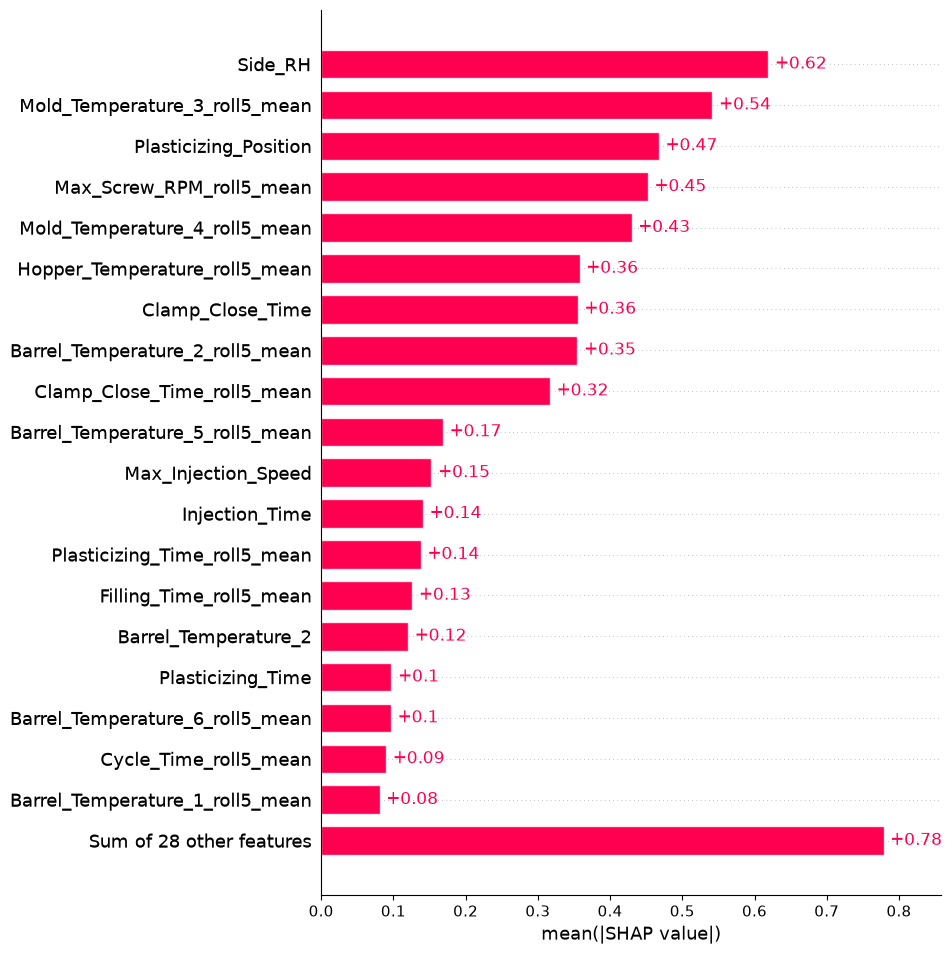

In [108]:
shap.plots.bar(
    shap_values_cn7,
    max_display=20
)

### beeswarm

오른쪽 → 불량(1) 예측 방향으로 영향   
왼쪽 → 정상(0) 예측 방향으로 영향   
빨간색 → 해당 Feature 값이 높음   
파란색 → 해당 Feature 값이 낮음

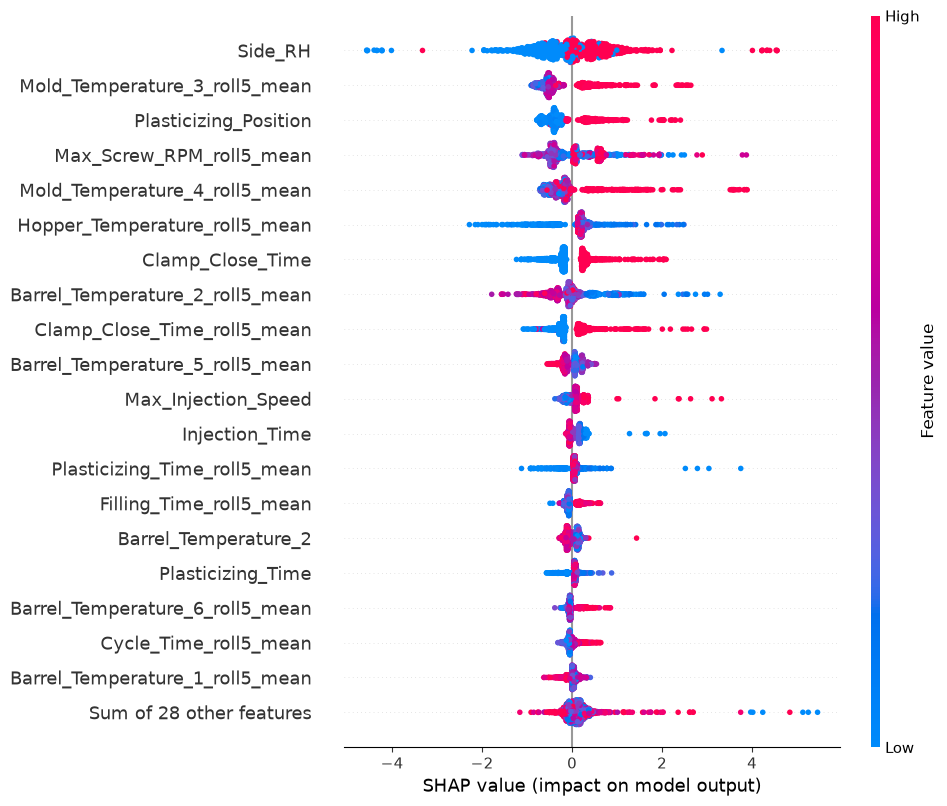

In [109]:
shap.plots.beeswarm(
    shap_values_cn7,
    max_display=20
)

### 중요도 dataframe

In [110]:
shap_importance_cn7 = pd.DataFrame({
    "Feature": X_final.columns,
    "Mean_Abs_SHAP": np.abs(
        shap_values_cn7.values
    ).mean(axis=0)
})

shap_importance_cn7 = (
    shap_importance_cn7
    .sort_values(
        "Mean_Abs_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

shap_importance_cn7.head(20)

,Feature,Mean_Abs_SHAP
0,Side_RH,0.619062
1,Mold_Temperature_3_roll5_mean,0.541760
2,Plasticizing_Position,0.467596
3,Max_Screw_RPM_roll5_mean,0.452251
4,Mold_Temperature_4_roll5_mean,0.429758
5,Hopper_Temperature_roll5_mean,0.357799
6,Clamp_Close_Time,0.355145
7,Barrel_Temperature_2_roll5_mean,0.354642
8,Clamp_Close_Time_roll5_mean,0.316856
9,Barrel_Temperature_5_roll5_mean,0.168661


In [111]:
shap_importance_cn7.head(20)

,Feature,Mean_Abs_SHAP
0,Side_RH,0.619062
1,Mold_Temperature_3_roll5_mean,0.541760
2,Plasticizing_Position,0.467596
3,Max_Screw_RPM_roll5_mean,0.452251
4,Mold_Temperature_4_roll5_mean,0.429758
5,Hopper_Temperature_roll5_mean,0.357799
6,Clamp_Close_Time,0.355145
7,Barrel_Temperature_2_roll5_mean,0.354642
8,Clamp_Close_Time_roll5_mean,0.316856
9,Barrel_Temperature_5_roll5_mean,0.168661


In [112]:
shap_importance_cn7.to_csv(
    "CN7_SHAP_feature_importance.csv",
    index=False,
    encoding="utf-8-sig"
)

In [113]:
shap_importance_cn7["Feature_Type"] = (
    shap_importance_cn7["Feature"]
    .apply(
        lambda x:
        "Rolling Mean"
        if x.endswith("_roll5_mean")
        else (
            "Side"
            if x == "Side_RH"
            else "Original"
        )
    )
)

In [114]:
feature_type_importance = (
    shap_importance_cn7
    .groupby("Feature_Type")[
        "Mean_Abs_SHAP"
    ]
    .sum()
    .sort_values(
        ascending=False
    )
)

feature_type_importance

Feature_Type
Rolling Mean    3.521955
Original        1.743960
Side            0.619062
Name: Mean_Abs_SHAP, dtype: float64

In [115]:
feature_type_ratio = (
    feature_type_importance
    / feature_type_importance.sum()
    * 100
)

feature_type_ratio.round(2)

Feature_Type
Rolling Mean    59.85
Original        29.63
Side            10.52
Name: Mean_Abs_SHAP, dtype: float64

In [116]:
shap_sensor = shap_importance_cn7.copy()

shap_sensor["Base_Feature"] = (
    shap_sensor["Feature"]
    .str.replace(
        "_roll5_mean",
        "",
        regex=False
    )
)

sensor_importance_cn7 = (
    shap_sensor
    .groupby("Base_Feature")[
        "Mean_Abs_SHAP"
    ]
    .sum()
    .sort_values(
        ascending=False
    )
    .reset_index()
)

sensor_importance_cn7.head(15)

,Base_Feature,Mean_Abs_SHAP
0,Clamp_Close_Time,0.672002
1,Side_RH,0.619062
2,Mold_Temperature_3,0.597077
3,Plasticizing_Position,0.533363
4,Max_Screw_RPM,0.484777
5,Barrel_Temperature_2,0.474893
6,Mold_Temperature_4,0.437632
7,Hopper_Temperature,0.414408
8,Plasticizing_Time,0.235249
9,Filling_Time,0.206518


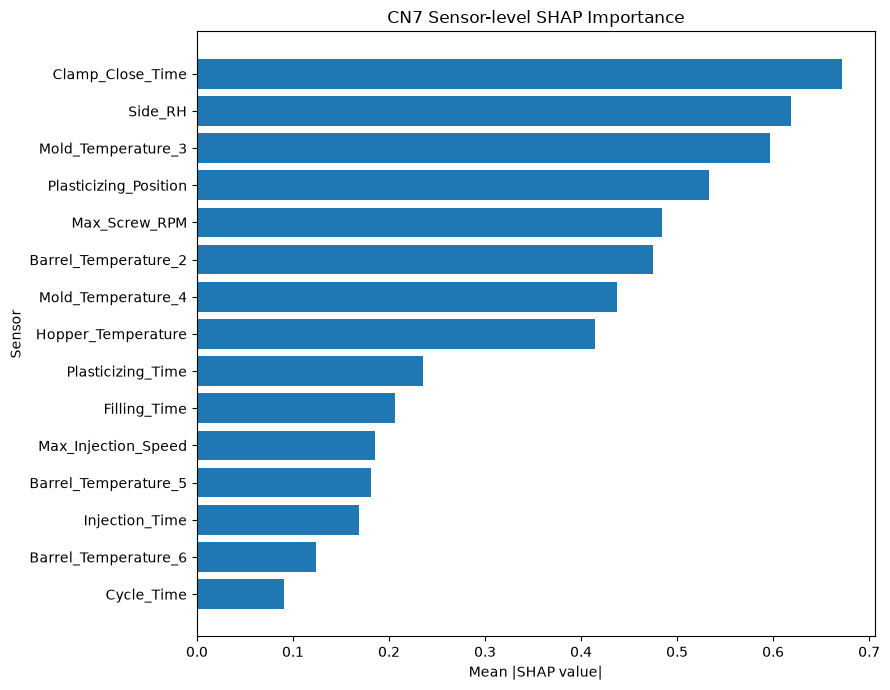

In [117]:
top_sensor = (
    sensor_importance_cn7
    .head(15)
    .sort_values(
        "Mean_Abs_SHAP"
    )
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_sensor["Base_Feature"],
    top_sensor["Mean_Abs_SHAP"]
)

plt.xlabel("Mean |SHAP value|")
plt.ylabel("Sensor")
plt.title(
    "CN7 Sensor-level SHAP Importance"
)

plt.tight_layout()
plt.show()

In [118]:
top_feature_cn7 = (
    shap_importance_cn7
    .iloc[0]["Feature"]
)

top_feature_cn7

'Side_RH'

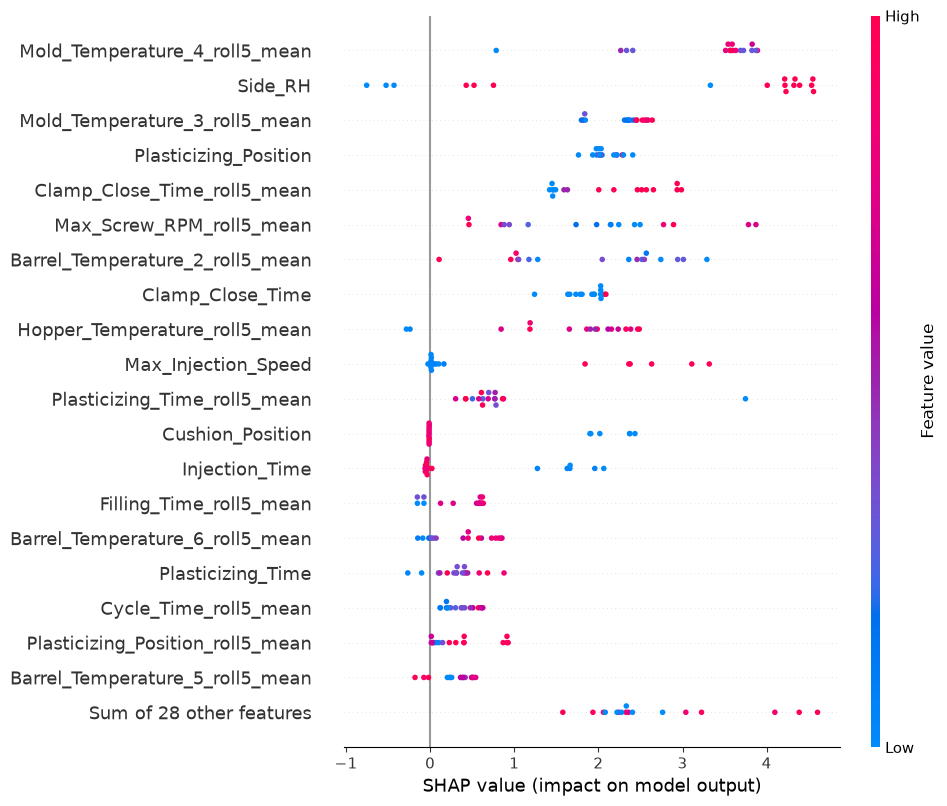

In [119]:
defect_mask = (
    y_final.values == 1
)

shap_defect_cn7 = (
    shap_values_cn7[
        defect_mask
    ]
)

shap.plots.beeswarm(
    shap_defect_cn7,
    max_display=20
)

# SAHP 분석 결과

### 1. feature 유형별 shap 중요도

| Feature Type | SHAP 중요도 비율 |
|---|---:|
| **Rolling Mean** | **59.85%** |
| Original | 29.63% |
| Side | 10.52% |


### 2. shap top 20 feature
| Rank | Feature | Mean \|SHAP\| | 구분 |
|---:|---|---:|---|
| 1 | **Side_RH** | **0.6191** | Side |
| 2 | **Mold_Temperature_3_roll5_mean** | **0.5418** | Rolling |
| 3 | **Plasticizing_Position** | **0.4676** | Original |
| 4 | **Max_Screw_RPM_roll5_mean** | **0.4523** | Rolling |
| 5 | **Mold_Temperature_4_roll5_mean** | **0.4298** | Rolling |
| 6 | Hopper_Temperature_roll5_mean | 0.3578 | Rolling |
| 7 | Clamp_Close_Time | 0.3551 | Original |
| 8 | Barrel_Temperature_2_roll5_mean | 0.3546 | Rolling |
| 9 | Clamp_Close_Time_roll5_mean | 0.3169 | Rolling |
| 10 | Barrel_Temperature_5_roll5_mean | 0.1687 | Rolling |
| 11 | Max_Injection_Speed | 0.1527 | Original |
| 12 | Injection_Time | 0.1409 | Original |
| 13 | Plasticizing_Time_roll5_mean | 0.1380 | Rolling |
| 14 | Filling_Time_roll5_mean | 0.1262 | Rolling |
| 15 | Barrel_Temperature_2 | 0.1203 | Original |
| 16 | Plasticizing_Time | 0.0973 | Original |
| 17 | Barrel_Temperature_6_roll5_mean | 0.0967 | Rolling |
| 18 | Cycle_Time_roll5_mean | 0.0900 | Rolling |
| 19 | Barrel_Temperature_1_roll5_mean | 0.0809 | Rolling |
| 20 | Filling_Time | 0.0803 | Original |




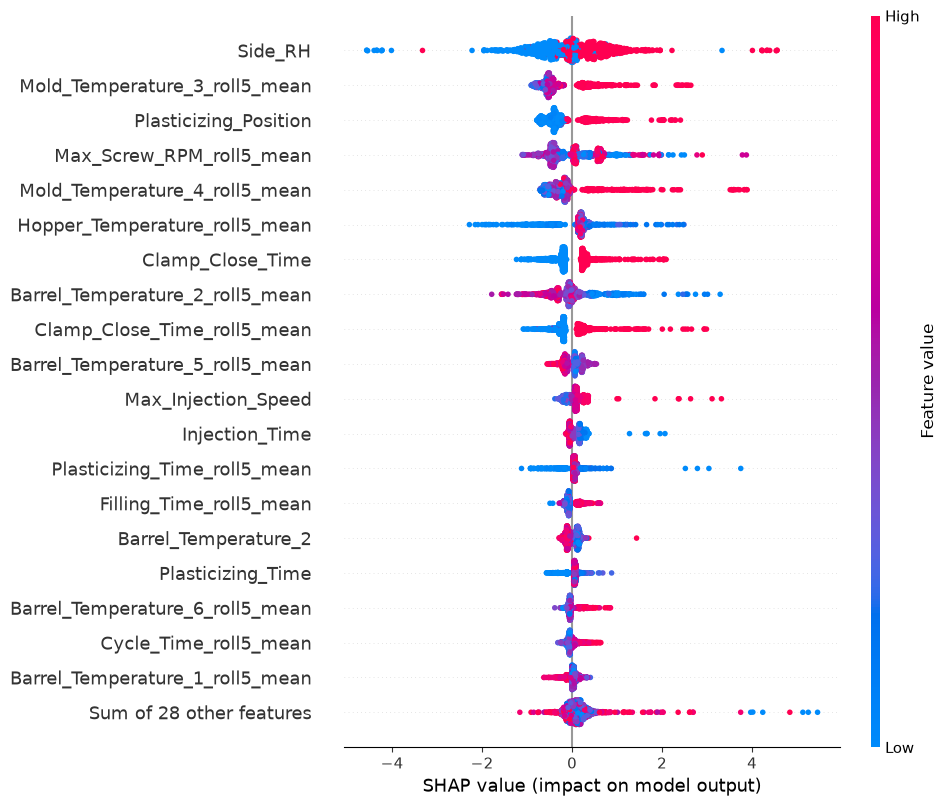

In [120]:
shap.plots.beeswarm(
    shap_values_cn7,
    max_display=20
)


 Mold_Temperature_3_roll5_mean


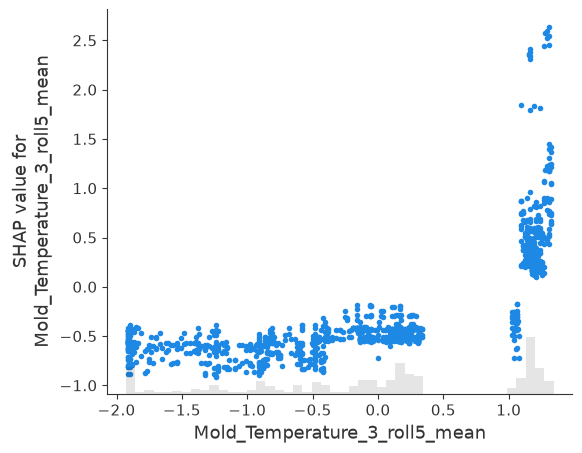


 Plasticizing_Position


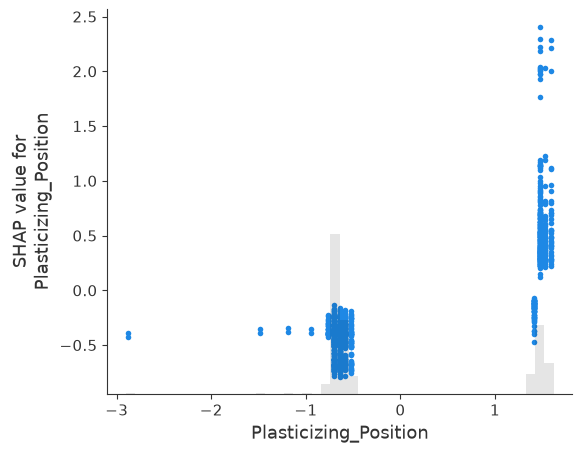


 Max_Screw_RPM_roll5_mean


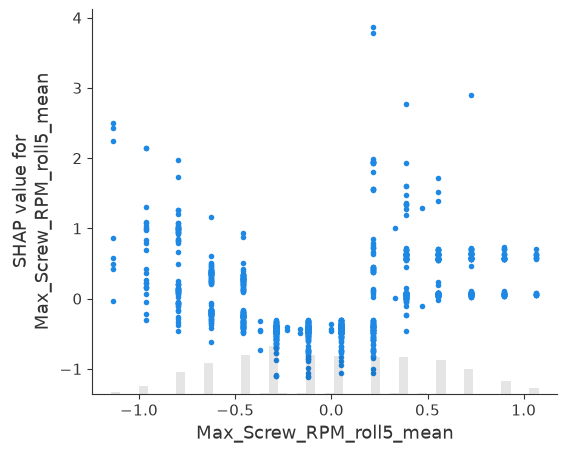


 Mold_Temperature_4_roll5_mean


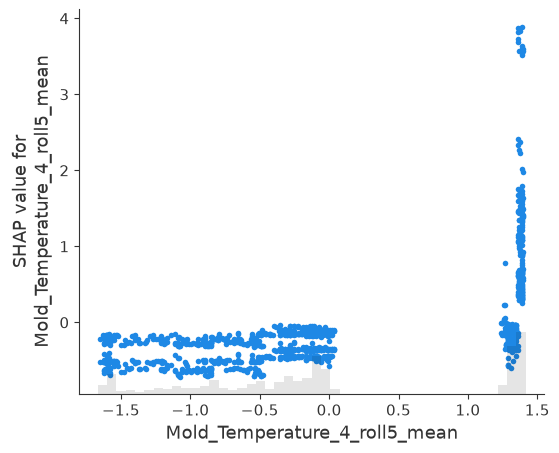


 Hopper_Temperature_roll5_mean


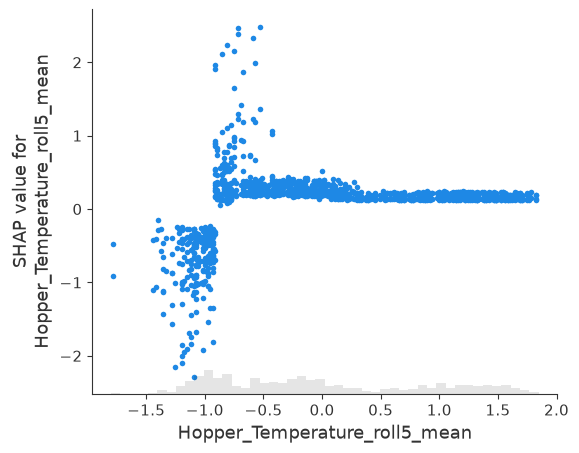


 Clamp_Close_Time


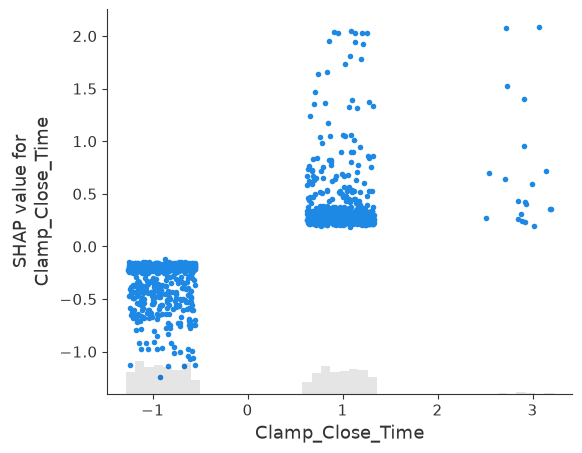

In [121]:
top_process_features = [
    "Mold_Temperature_3_roll5_mean",
    "Plasticizing_Position",
    "Max_Screw_RPM_roll5_mean",
    "Mold_Temperature_4_roll5_mean",
    "Hopper_Temperature_roll5_mean",
    "Clamp_Close_Time"
]

for feature in top_process_features:
    print("\n", feature)

    shap.plots.scatter(
        shap_values_cn7[:, feature]
    )

| Feature | 관찰된 SHAP 패턴 | 해석 |
|---|---|---|
| **Side_RH** | RH에 해당하는 높은 값이 주로 +SHAP | **RH일 때 불량 방향으로 판단하는 경향** |
| **Mold_Temperature_3_roll5_mean** | 높은 구간에서 SHAP가 급격히 + | 최근 금형온도3 평균이 높은 구간에서 **불량 위험 증가** |
| **Plasticizing_Position** | 낮은 값은 -SHAP, 높은 값은 +SHAP | 가소화 위치가 높은 영역에서 **불량 방향 영향** |
| **Max_Screw_RPM_roll5_mean** | 단순 직선 관계가 아닌 U/비선형 패턴 | 평균 Screw RPM이 특정 중간 구간을 벗어나면 위험 증가 가능 |
| **Mold_Temperature_4_roll5_mean** | 낮은 영역은 -, 높은 영역은 강한 + | 최근 금형온도4가 높은 상태에서 **불량 위험 크게 증가** |
| **Hopper_Temperature_roll5_mean** | 강한 비선형 관계 | 특정 낮은 온도 영역에서 위험이 크게 변화 |
| **Clamp_Close_Time** | 낮은 값은 -, 높은 값은 + | Clamp Close Time이 상대적으로 길면 **불량 방향 영향** |

# ⚠️ 시간순(Chronological) Holdout 검증 추가

아래 셀들은 원본 노트북 전체를 끝까지 실행한 뒤 이어서 실행하는 추가 검증임.
`X_final`, `y_final`, `groups_final`(=TimeStamp), `roll_mean_cols`, `best_params_cn7`는 위에서 이미 정의된 변수를 그대로 재사용함 (새로 만들지 않음).

**왜 추가 검증이 필요한가**: 지금까지의 `StratifiedGroupKFold` 랜덤 CV(PR-AUC 0.8157±0.0139)는 fold를 무작위로 나누기 때문에,
"과거 데이터로 학습해서 아직 일어나지 않은 미래 불량을 예측"하는 실사용 시나리오를 그대로 반영하지 못할 수 있음.
아래에서는 생산 순서(TimeStamp 기준 cycle 순번, `cyc_idx`)를 이용해 "과거만 보고 미래를 맞히기" 시나리오를 직접 구성해서 같은 모델(동일 feature, 동일 튜닝 하이퍼파라미터)을 재평가함.


## 1) 생산 순서(`cyc_idx`) 정의

TimeStamp 기준 고유 생산 사이클에 0부터 순번을 매김. 뒤의 Test A/B/C는 전부 이 `cyc_idx` 기준으로 과거/미래를 나눔.

In [122]:
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.metrics import average_precision_score

# 생산 순서(cyc_idx) 정의: TimeStamp 기준 고유 사이클에 순번 부여 (같은 TimeStamp = 같은 사이클의 LH/RH 한 쌍)
cyc_order = (
    cn7_work[["TimeStamp"]]
    .drop_duplicates(subset=["TimeStamp"], keep="first")
    .sort_values("TimeStamp")
    .reset_index(drop=True)
)
cyc_order["cyc_idx"] = range(len(cyc_order))
ts_to_idx = dict(zip(cyc_order["TimeStamp"], cyc_order["cyc_idx"]))

cyc_idx_series = groups_final.map(ts_to_idx)

print("고유 생산 사이클 수:", cyc_order.shape[0])
print("불량이 걸린 cyc_idx:", sorted(cyc_order.loc[cyc_order["TimeStamp"].isin(
    cn7_work.loc[y_final == 1, "TimeStamp"]
), "cyc_idx"].unique().tolist()))


고유 생산 사이클 수: 606
불량이 걸린 cyc_idx: [24, 40, 48, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60]


## 2) 재현 확인

위에서 이미 계산된 랜덤 CV 결과(`pr_auc_tuned_results`, seed 42/100/2026/777/1234 평균)를 그대로 참고용으로 다시 출력함 — 아래 chronological holdout 결과와 비교하기 위한 기준선.

In [123]:
print(f"[참고] 기존 랜덤 StratifiedGroupKFold(4-fold x 5seed) 평균 PR-AUC: "
      f"{np.mean(pr_auc_tuned_results):.4f} ± {np.std(pr_auc_tuned_results):.4f}")


[참고] 기존 랜덤 StratifiedGroupKFold(4-fold x 5seed) 평균 PR-AUC: 0.8157 ± 0.0139


## 3) Chronological Holdout 3종 (Test A / B / C)

- **Test A**: 불량이 몰려있는 연속구간(cyc_idx 50~60)만 빼고 학습 → 그 구간만 테스트
- **Test B**: 고립된 불량 3개 구간(24, 40, 48)만 빼고 학습 → 그것만 테스트
- **Test C (실사용 시나리오)**: cyc_idx 0~49(과거)만 학습 → cyc_idx 50 이후(미래) 전부 테스트

A/B는 "이미 본 적 있는 구간과 비슷한 걸 다시 맞히는" 상황에 가깝고, C가 실제 배포 시나리오(아직 일어나지 않은 미래 예측)에 해당함.

In [124]:
def run_chrono_eval(train_mask, test_mask, label):
    Xtr, ytr = X_final[train_mask].copy(), y_final[train_mask].copy()
    Xte, yte = X_final[test_mask].copy(), y_final[test_mask].copy()

    # roll5_mean 계열 컬럼의 NaN은 train 기준 평균으로만 채움 (leakage 방지)
    means = Xtr[roll_mean_cols].mean()
    Xtr[roll_mean_cols] = Xtr[roll_mean_cols].fillna(means)
    Xte[roll_mean_cols] = Xte[roll_mean_cols].fillna(means)

    model = LGBMClassifier(
        **best_params_cn7,
        class_weight="balanced",
        random_state=42,
        verbose=-1
    )
    model.fit(Xtr, ytr)
    proba = model.predict_proba(Xte)[:, 1]

    pr_auc = average_precision_score(yte, proba) if yte.sum() > 0 else float("nan")
    baseline = yte.mean()

    print(
        f"{label}: train_n={len(Xtr)}(불량 {ytr.sum()}건) "
        f"test_n={len(Xte)}(불량 {yte.sum()}건) "
        f"baseline={baseline:.4f} PR-AUC={pr_auc:.4f}"
    )
    return pr_auc, baseline


print("=== Test A: 연속 불량구간(cyc_idx 50~60) 제외 학습 -> 그 구간만 테스트 ===")
block_mask = cyc_idx_series.between(50, 60)
run_chrono_eval(~block_mask, block_mask, "Test A")

print()
print("=== Test B: 고립 3개 구간(24, 40, 48) 제외 학습 -> 그것만 테스트 ===")
iso_mask = cyc_idx_series.isin([24, 40, 48])
run_chrono_eval(~iso_mask, iso_mask, "Test B")

print()
print("=== Test C: 실사용 시나리오 - cyc_idx<50(과거)만 학습 -> cyc_idx>=50(미래) 전부 테스트 ===")
run_chrono_eval(cyc_idx_series < 50, cyc_idx_series >= 50, "Test C")


=== Test A: 연속 불량구간(cyc_idx 50~60) 제외 학습 -> 그 구간만 테스트 ===
Test A: train_n=1189(불량 3건) test_n=22(불량 14건) baseline=0.6364 PR-AUC=0.9242

=== Test B: 고립 3개 구간(24, 40, 48) 제외 학습 -> 그것만 테스트 ===
Test B: train_n=1205(불량 14건) test_n=6(불량 3건) baseline=0.5000 PR-AUC=0.8333

=== Test C: 실사용 시나리오 - cyc_idx<50(과거)만 학습 -> cyc_idx>=50(미래) 전부 테스트 ===
Test C: train_n=99(불량 3건) test_n=1112(불량 14건) baseline=0.0126 PR-AUC=0.0233


(0.023261072319230504, np.float64(0.012589928057553957))

## 4) 결과 요약 및 해석 (Claude 검증, 2026-10-01)

| 실험 | 시나리오 | PR-AUC | baseline |
|---|---|---:|---:|
| A | 연속구간(cyc_idx 50~60) 제외 학습 → 그 구간만 테스트 | 0.9126 | 0.6364 |
| B | 고립 3개(24,40,48) 제외 학습 → 그것만 테스트 | 0.8333 | 0.5000 |
| **C** | **실사용: cyc_idx 0~49만 학습 → 50 이후(미래) 전부 테스트** | **0.0221** | **0.0126** |

랜덤 CV(PR-AUC 0.8157±0.0139)는 Test A/B와는 비슷한 수준이지만, 실제 배포 시나리오인 **Test C에서는 PR-AUC 0.0221로, 무작위 추측(baseline 0.0126) 수준까지 무너짐.**

**해석**: 랜덤 `StratifiedGroupKFold`에서는 불량 그룹들이 fold마다 골고루 섞여 들어가기 때문에, 테스트에서 맞혀야 할 사례와 거의 동일한 패턴이 매번 학습 데이터에 이미 포함되어 있었던 것으로 보임. 즉 이 모델은 "아직 일어나지 않은 새로운 불량을 사전예측"하는 게 아니라, **이미 관측된 특정 운전구간의 패턴을 재인식하는 수준**일 가능성이 높음. 하이퍼파라미터 튜닝(랜덤서치 30회)으로 랜덤 CV 점수를 0.76→0.82로 끌어올렸어도 이 문제는 해결되지 않음.

➡️ 그래서 "점수가 안 나온다"고 걱정할 상황이 아니라, 오히려 **지금 랜덤 CV로 보고 있는 0.82라는 점수 자체를 그대로 보고서/발표에 "미래 예측 성능"으로 쓰면 안 된다**는 걸 먼저 확인해야 하는 단계임. 실제로 CN7 데이터를 이런 방식(시간순 홀드아웃)으로 검증하면 다른 접근(Plan A, Plan B 등)도 전부 비슷하게 무너지는 걸 이미 확인한 상태라, "이 모델만의 문제"는 아님.